In [1]:
import os, shutil, random

SOURCE_DIR = r"C:\Users\user\Desktop\Skin Detector\archive\dataset"
TARGET_DIR = r"C:\Users\user\Desktop\Skin Detector\archive\dataset_balanced_1800"

IMAGES_PER_CLASS = 300
random.seed(42)

for split in ["train", "val", "test"]:
    os.makedirs(os.path.join(TARGET_DIR, split), exist_ok=True)

    for cls in os.listdir(os.path.join(SOURCE_DIR, split)):
        src_cls = os.path.join(SOURCE_DIR, split, cls)
        if not os.path.isdir(src_cls):
            continue

        dst_cls = os.path.join(TARGET_DIR, split, cls)
        os.makedirs(dst_cls, exist_ok=True)

        images = os.listdir(src_cls)

        if len(images) < IMAGES_PER_CLASS:
            print(f"⚠️ {cls} ({split}) has only {len(images)} images — using all")
            selected = images
        else:
            selected = random.sample(images, IMAGES_PER_CLASS)

        for img in selected:
            shutil.copy(
                os.path.join(src_cls, img),
                os.path.join(dst_cls, img)
            )

print("✅ BALANCED DATASET (1500–2000 RANGE) CREATED")


⚠️ Acne (train) has only 197 images — using all
⚠️ Eczema (train) has only 203 images — using all
⚠️ Psoriasis (train) has only 193 images — using all
⚠️ Rosacea (train) has only 150 images — using all
⚠️ Vitiligo (train) has only 222 images — using all
⚠️ Warts (train) has only 196 images — using all
⚠️ Acne (val) has only 60 images — using all
⚠️ Eczema (val) has only 61 images — using all
⚠️ Psoriasis (val) has only 60 images — using all
⚠️ Rosacea (val) has only 32 images — using all
⚠️ Vitiligo (val) has only 60 images — using all
⚠️ Warts (val) has only 57 images — using all
⚠️ Acne (test) has only 60 images — using all
⚠️ Eczema (test) has only 64 images — using all
⚠️ Psoriasis (test) has only 56 images — using all
⚠️ Rosacea (test) has only 33 images — using all
⚠️ Vitiligo (test) has only 62 images — using all
⚠️ Warts (test) has only 63 images — using all
✅ BALANCED DATASET (1500–2000 RANGE) CREATED


In [2]:
print("\n🔎 FINAL BALANCED DATASET COUNT")

def verify(base_dir):
    total = 0
    for split in ["train", "val", "test"]:
        print(f"\n{split.upper()}")
        split_total = 0
        for cls in os.listdir(os.path.join(base_dir, split)):
            count = len(os.listdir(os.path.join(base_dir, split, cls)))
            print(f"{cls}: {count}")
            split_total += count
        print("Split total:", split_total)
        total += split_total
    print("\nTOTAL IMAGES:", total)

verify(TARGET_DIR)



🔎 FINAL BALANCED DATASET COUNT

TRAIN
Acne: 197
Eczema: 203
Psoriasis: 193
Rosacea: 150
Vitiligo: 222
Warts: 196
Split total: 1161

VAL
Acne: 60
Eczema: 61
Psoriasis: 60
Rosacea: 32
Vitiligo: 60
Warts: 57
Split total: 330

TEST
Acne: 60
Eczema: 64
Psoriasis: 56
Rosacea: 33
Vitiligo: 62
Warts: 63
Split total: 338

TOTAL IMAGES: 1829


In [3]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models


In [7]:
DATASET_DIR = r"C:\Users\user\Desktop\Skin Detector\archive\dataset_balanced_1800"
TRAIN_DIR = os.path.join(DATASET_DIR, "train")
VAL_DIR   = os.path.join(DATASET_DIR, "val")
TEST_DIR  = os.path.join(DATASET_DIR, "test")

IMG_SIZE = 224
BATCH = 16
EPOCHS_1 = 15   # initial training
EPOCHS_2 = 10   # fine-tuning

print("✅ Paths set")


✅ Paths set


In [8]:
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

val_test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH,
    class_mode="categorical"
)

val_data = val_test_gen.flow_from_directory(
    VAL_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH,
    class_mode="categorical"
)

test_data = val_test_gen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH,
    class_mode="categorical",
    shuffle=False
)

class_names = list(train_data.class_indices.keys())
NUM_CLASSES = train_data.num_classes

print("✅ Classes:", class_names)
print("✅ Num classes:", NUM_CLASSES)


Found 1161 images belonging to 6 classes.
Found 330 images belonging to 6 classes.
Found 338 images belonging to 6 classes.
✅ Classes: ['Acne', 'Eczema', 'Psoriasis', 'Rosacea', 'Vitiligo', 'Warts']
✅ Num classes: 6


In [9]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False  # freeze base

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 6)                   │             774 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [10]:
MODEL_DIR = r"C:\Users\user\Desktop\Skin Detector\archive\models"
os.makedirs(MODEL_DIR, exist_ok=True)

BEST_MODEL_PATH = os.path.join(MODEL_DIR, "skin_detector_best_6cls.keras")

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        BEST_MODEL_PATH, monitor="val_accuracy", save_best_only=True, verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=5, restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.3, patience=3, min_lr=1e-6, verbose=1
    )
]

print("✅ Callbacks ready")


✅ Callbacks ready


In [11]:
history1 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS_1,
    callbacks=callbacks
)


Epoch 1/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2185 - loss: 2.0815  
Epoch 1: val_accuracy improved from None to 0.41212, saving model to C:\Users\user\Desktop\Skin Detector\archive\models\skin_detector_best_6cls.keras
73/73 ━━━━━━━━━━━━━━━━━━━━ 158s 2s/step - accuracy: 0.2739 - loss: 1.9195 - val_accuracy: 0.4121 - val_loss: 1.4686 - learning_rate: 1.0000e-04
Epoch 2/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3863 - loss: 1.5798  
Epoch 2: val_accuracy improved from 0.41212 to 0.49394, saving model to C:\Users\user\Desktop\Skin Detector\archive\models\skin_detector_best_6cls.keras
73/73 ━━━━━━━━━━━━━━━━━━━━ 97s 1s/step - accuracy: 0.3781 - loss: 1.5557 - val_accuracy: 0.4939 - val_loss: 1.2847 - learning_rate: 1.0000e-04
Epoch 3/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4294 - loss: 1.4158  
Epoch 3: val_accuracy improved from 0.49394 to 0.53636, saving model to C:\Users\user\Desktop\Skin Detector\archive\models\skin_detector_best_6cls.keras
73

In [12]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history2 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS_2,
    callbacks=callbacks
)


Epoch 1/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2637 - loss: 2.5134  
Epoch 1: val_accuracy did not improve from 0.69091
73/73 ━━━━━━━━━━━━━━━━━━━━ 145s 1s/step - accuracy: 0.3058 - loss: 2.2000 - val_accuracy: 0.6545 - val_loss: 0.8784 - learning_rate: 1.0000e-05
Epoch 2/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4189 - loss: 1.4737  
Epoch 2: val_accuracy did not improve from 0.69091
73/73 ━━━━━━━━━━━━━━━━━━━━ 105s 1s/step - accuracy: 0.4436 - loss: 1.3829 - val_accuracy: 0.6455 - val_loss: 0.9060 - learning_rate: 1.0000e-05
Epoch 3/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5219 - loss: 1.2008  
Epoch 3: val_accuracy did not improve from 0.69091

Epoch 3: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.
73/73 ━━━━━━━━━━━━━━━━━━━━ 119s 2s/step - accuracy: 0.5332 - loss: 1.1856 - val_accuracy: 0.6333 - val_loss: 0.9221 - learning_rate: 1.0000e-05
Epoch 4/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5583 - loss: 1.1416

In [13]:
best_model = tf.keras.models.load_model(BEST_MODEL_PATH)

test_loss, test_acc = best_model.evaluate(test_data)
print(f"✅ Test Accuracy: {test_acc*100:.2f}%")


22/22 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 0.6331 - loss: 0.9233   
✅ Test Accuracy: 63.31%


22/22 ━━━━━━━━━━━━━━━━━━━━ 26s 882ms/step
              precision    recall  f1-score   support

        Acne       0.57      0.73      0.64        60
      Eczema       0.53      0.78      0.63        64
   Psoriasis       0.51      0.43      0.47        56
     Rosacea       0.63      0.79      0.70        33
    Vitiligo       0.98      0.81      0.88        62
       Warts       0.71      0.32      0.44        63

    accuracy                           0.63       338
   macro avg       0.66      0.64      0.63       338
weighted avg       0.66      0.63      0.62       338



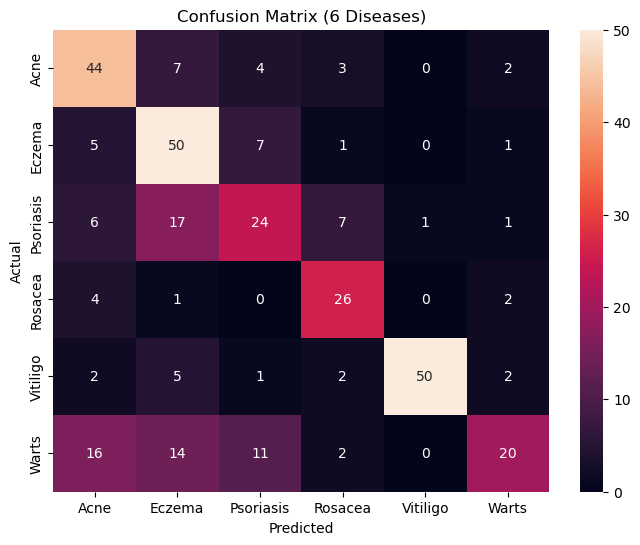

In [14]:
from sklearn.metrics import classification_report, confusion_matrix

y_true = test_data.classes
y_pred_probs = best_model.predict(test_data)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (6 Diseases)")
plt.show()


In [18]:
import sys, tensorflow as tf
print("✅ Python:", sys.version)
print("✅ TensorFlow:", tf.__version__)
print("✅ Eager:", tf.executing_eagerly())


✅ Python: 3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 16:37:03) [MSC v.1929 64 bit (AMD64)]
✅ TensorFlow: 2.20.0
✅ Eager: True


In [21]:
import os

DATASET_DIR = r"C:\Users\user\Desktop\Skin Detector\archive\dataset"  # ✅ apna folder

TRAIN_DIR = os.path.join(DATASET_DIR, "train")
VAL_DIR   = os.path.join(DATASET_DIR, "val")
TEST_DIR  = os.path.join(DATASET_DIR, "test")

print("DATASET_DIR:", DATASET_DIR)
print("TRAIN exists:", os.path.exists(TRAIN_DIR), TRAIN_DIR)
print("VAL exists:", os.path.exists(VAL_DIR), VAL_DIR)
print("TEST exists:", os.path.exists(TEST_DIR), TEST_DIR)


DATASET_DIR: C:\Users\user\Desktop\Skin Detector\archive\dataset
TRAIN exists: True C:\Users\user\Desktop\Skin Detector\archive\dataset\train
VAL exists: True C:\Users\user\Desktop\Skin Detector\archive\dataset\val
TEST exists: True C:\Users\user\Desktop\Skin Detector\archive\dataset\test


In [22]:
classes = [d for d in os.listdir(TRAIN_DIR) if os.path.isdir(os.path.join(TRAIN_DIR, d))]
print("✅ Found classes in TRAIN:", classes)
print("✅ Total classes:", len(classes))


✅ Found classes in TRAIN: ['Acne', 'Eczema', 'Psoriasis', 'Rosacea', 'Vitiligo', 'Warts']
✅ Total classes: 6


In [23]:
def count_split(split_dir):
    counts = {}
    for cls in sorted(os.listdir(split_dir)):
        cls_path = os.path.join(split_dir, cls)
        if os.path.isdir(cls_path):
            counts[cls] = len([f for f in os.listdir(cls_path)
                              if f.lower().endswith((".jpg",".jpeg",".png",".webp"))])
    return counts

for split_name, split_dir in [("train", TRAIN_DIR), ("val", VAL_DIR), ("test", TEST_DIR)]:
    counts = count_split(split_dir)
    print(f"\n📁 {split_name.upper()} counts:")
    for k,v in counts.items():
        print(f"  {k}: {v}")
    print("  TOTAL:", sum(counts.values()))



📁 TRAIN counts:
  Acne: 197
  Eczema: 203
  Psoriasis: 193
  Rosacea: 150
  Vitiligo: 222
  Warts: 196
  TOTAL: 1161

📁 VAL counts:
  Acne: 60
  Eczema: 61
  Psoriasis: 60
  Rosacea: 32
  Vitiligo: 60
  Warts: 57
  TOTAL: 330

📁 TEST counts:
  Acne: 60
  Eczema: 64
  Psoriasis: 56
  Rosacea: 33
  Vitiligo: 62
  Warts: 63
  TOTAL: 338


In [24]:
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 224
BATCH = 16

train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    brightness_range=[0.8, 1.2],
    horizontal_flip=True
)

val_test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH,
    class_mode="categorical"
)

val_data = val_test_gen.flow_from_directory(
    VAL_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH,
    class_mode="categorical"
)

test_data = val_test_gen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH,
    class_mode="categorical",
    shuffle=False
)

class_names = list(train_data.class_indices.keys())
print("✅ class_indices:", train_data.class_indices)
print("✅ class_names order:", class_names)
print("✅ num_classes:", train_data.num_classes)


Found 1161 images belonging to 6 classes.
Found 330 images belonging to 6 classes.
Found 338 images belonging to 6 classes.
✅ class_indices: {'Acne': 0, 'Eczema': 1, 'Psoriasis': 2, 'Rosacea': 3, 'Vitiligo': 4, 'Warts': 5}
✅ class_names order: ['Acne', 'Eczema', 'Psoriasis', 'Rosacea', 'Vitiligo', 'Warts']
✅ num_classes: 6


In [25]:
import tensorflow as tf
from tensorflow.keras import layers, models

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(train_data.num_classes, activation="softmax")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 6)                   │             774 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [26]:
import os
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

MODEL_DIR = r"C:\Users\user\Desktop\Skin Detector\archive\models"
os.makedirs(MODEL_DIR, exist_ok=True)

BEST_MODEL_PATH = os.path.join(MODEL_DIR, "skin_detector_best_6cls.keras")

checkpoint = ModelCheckpoint(BEST_MODEL_PATH, monitor="val_accuracy", save_best_only=True, verbose=1)
early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1)
reduce_lr  = ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=3, min_lr=1e-6, verbose=1)

EPOCHS = 20

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS,
    callbacks=[checkpoint, early_stop, reduce_lr]
)

print("✅ Saved best model to:", BEST_MODEL_PATH)


Epoch 1/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2392 - loss: 1.9767     
Epoch 1: val_accuracy improved from None to 0.46667, saving model to C:\Users\user\Desktop\Skin Detector\archive\models\skin_detector_best_6cls.keras
73/73 ━━━━━━━━━━━━━━━━━━━━ 143s 2s/step - accuracy: 0.2946 - loss: 1.8504 - val_accuracy: 0.4667 - val_loss: 1.4023 - learning_rate: 1.0000e-04
Epoch 2/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3902 - loss: 1.6145  
Epoch 2: val_accuracy improved from 0.46667 to 0.56970, saving model to C:\Users\user\Desktop\Skin Detector\archive\models\skin_detector_best_6cls.keras
73/73 ━━━━━━━━━━━━━━━━━━━━ 151s 2s/step - accuracy: 0.4358 - loss: 1.4990 - val_accuracy: 0.5697 - val_loss: 1.2016 - learning_rate: 1.0000e-04
Epoch 3/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4801 - loss: 1.3855  
Epoch 3: val_accuracy improved from 0.56970 to 0.59394, saving model to C:\Users\user\Desktop\Skin Detector\archive\models\skin_detector_best_6cls.kera

In [27]:
base_model.trainable = True
for layer in base_model.layers[:-40]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_ft = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=[checkpoint, early_stop, reduce_lr]
)


Epoch 1/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2651 - loss: 2.5921  
Epoch 1: val_accuracy did not improve from 0.76970
73/73 ━━━━━━━━━━━━━━━━━━━━ 175s 2s/step - accuracy: 0.3333 - loss: 2.1424 - val_accuracy: 0.7515 - val_loss: 0.7063 - learning_rate: 1.0000e-05
Epoch 2/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4461 - loss: 1.5260  
Epoch 2: val_accuracy did not improve from 0.76970
73/73 ━━━━━━━━━━━━━━━━━━━━ 122s 2s/step - accuracy: 0.4849 - loss: 1.3726 - val_accuracy: 0.7273 - val_loss: 0.7491 - learning_rate: 1.0000e-05
Epoch 3/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5681 - loss: 1.0848  
Epoch 3: val_accuracy did not improve from 0.76970

Epoch 3: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.
73/73 ━━━━━━━━━━━━━━━━━━━━ 112s 2s/step - accuracy: 0.5607 - loss: 1.1094 - val_accuracy: 0.6939 - val_loss: 0.8036 - learning_rate: 1.0000e-05
Epoch 4/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5796 - loss: 1.0685

In [28]:
# Fine-tune MORE layers
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(5e-6),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_ft2 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    callbacks=[checkpoint, early_stop, reduce_lr]
)


Epoch 1/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4529 - loss: 1.3501  
Epoch 1: val_accuracy did not improve from 0.76970
73/73 ━━━━━━━━━━━━━━━━━━━━ 139s 2s/step - accuracy: 0.4858 - loss: 1.3155 - val_accuracy: 0.7485 - val_loss: 0.7120 - learning_rate: 5.0000e-06
Epoch 2/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5733 - loss: 1.1331  
Epoch 2: val_accuracy did not improve from 0.76970
73/73 ━━━━━━━━━━━━━━━━━━━━ 103s 1s/step - accuracy: 0.5633 - loss: 1.1338 - val_accuracy: 0.7333 - val_loss: 0.7226 - learning_rate: 5.0000e-06
Epoch 3/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5571 - loss: 1.1361  
Epoch 3: val_accuracy did not improve from 0.76970

Epoch 3: ReduceLROnPlateau reducing learning rate to 1.4999999621068127e-06.
73/73 ━━━━━━━━━━━━━━━━━━━━ 103s 1s/step - accuracy: 0.5754 - loss: 1.0887 - val_accuracy: 0.7333 - val_loss: 0.7326 - learning_rate: 5.0000e-06
Epoch 4/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5888 - loss: 0.9923

In [29]:
# STEP 8: Fine-tuning (unfreeze last layers)

base_model.trainable = True

# Sirf last 20 layers trainable
for layer in base_model.layers[:-20]:
    layer.trainable = False

print("Trainable layers:", sum(l.trainable for l in model.layers))


Trainable layers: 6


In [30]:
# STEP 9: Recompile with very low LR

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-6),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


In [31]:
# STEP 10: Fine-tuning training

EPOCHS = 15

history_finetune = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS,
    callbacks=[checkpoint, early_stop, reduce_lr]
)


Epoch 1/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5638 - loss: 1.1516  
Epoch 1: val_accuracy did not improve from 0.76970
73/73 ━━━━━━━━━━━━━━━━━━━━ 143s 2s/step - accuracy: 0.5711 - loss: 1.1158 - val_accuracy: 0.7333 - val_loss: 0.7224 - learning_rate: 5.0000e-06
Epoch 2/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5464 - loss: 1.1131  
Epoch 2: val_accuracy did not improve from 0.76970
73/73 ━━━━━━━━━━━━━━━━━━━━ 107s 1s/step - accuracy: 0.5633 - loss: 1.0871 - val_accuracy: 0.7333 - val_loss: 0.7330 - learning_rate: 5.0000e-06
Epoch 3/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6008 - loss: 1.0109  
Epoch 3: val_accuracy did not improve from 0.76970

Epoch 3: ReduceLROnPlateau reducing learning rate to 1.4999999621068127e-06.
73/73 ━━━━━━━━━━━━━━━━━━━━ 107s 1s/step - accuracy: 0.6115 - loss: 1.0087 - val_accuracy: 0.7303 - val_loss: 0.7396 - learning_rate: 5.0000e-06
Epoch 4/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5980 - loss: 1.0285

In [32]:
# STEP 11: Evaluate on test data

test_loss, test_acc = model.evaluate(test_data)
print(f"✅ Test Accuracy after fine-tuning: {test_acc*100:.2f}%")


22/22 ━━━━━━━━━━━━━━━━━━━━ 11s 486ms/step - accuracy: 0.6953 - loss: 0.8240
✅ Test Accuracy after fine-tuning: 69.53%


22/22 ━━━━━━━━━━━━━━━━━━━━ 21s 759ms/step
              precision    recall  f1-score   support

        Acne       0.59      0.83      0.69        60
      Eczema       0.63      0.84      0.72        64
   Psoriasis       0.61      0.55      0.58        56
     Rosacea       0.64      0.70      0.67        33
    Vitiligo       1.00      0.77      0.87        62
       Warts       0.91      0.46      0.61        63

    accuracy                           0.70       338
   macro avg       0.73      0.69      0.69       338
weighted avg       0.74      0.70      0.69       338



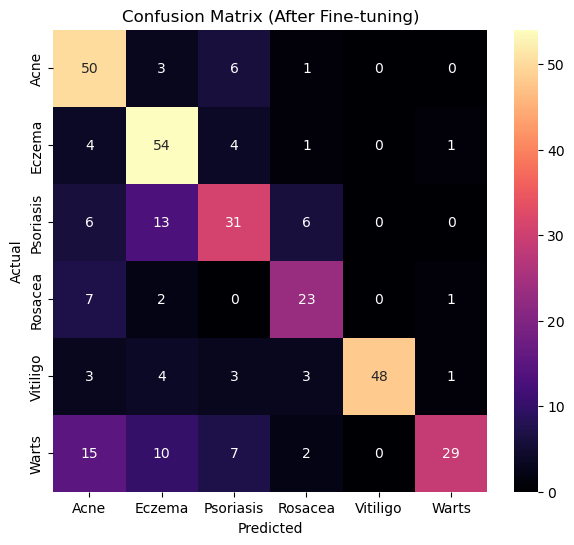

In [33]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

y_true = test_data.classes
y_pred = np.argmax(model.predict(test_data), axis=1)

class_names = list(test_data.class_indices.keys())

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="magma")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (After Fine-tuning)")
plt.show()


In [41]:
# ================= RECOMMENDATIONS DICTIONARY =================

recommendations = {
    "Acne": [
        "Benzoyl Peroxide",
        "Salicylic Acid",
        "Topical Retinoids",
        "Consult Dermatologist"
    ],
    "Eczema": [
        "Moisturizers",
        "Topical Corticosteroids",
        "Avoid Allergens",
        "Consult Dermatologist"
    ],
    "Psoriasis": [
        "Topical Corticosteroids",
        "Vitamin D Analogues",
        "Phototherapy",
        "Consult Dermatologist"
    ],
    "Rosacea": [
        "Metronidazole Cream",
        "Azelaic Acid",
        "Sun Protection",
        "Consult Dermatologist"
    ],
    "Vitiligo": [
        "Topical Corticosteroids",
        "Phototherapy",
        "Consult Dermatologist"
    ],
    "Warts": [
        "Salicylic Acid",
        "Cryotherapy",
        "Consult Dermatologist"
    ]
}



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step


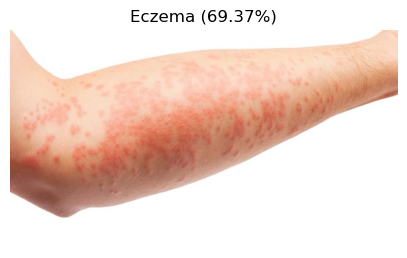

🧬 Detected Disease: Eczema
🧪 Disease Percentage: 69.37 %

💊 Recommended Treatment:
• Moisturizers
• Topical Corticosteroids
• Avoid Allergens
• Consult Dermatologist


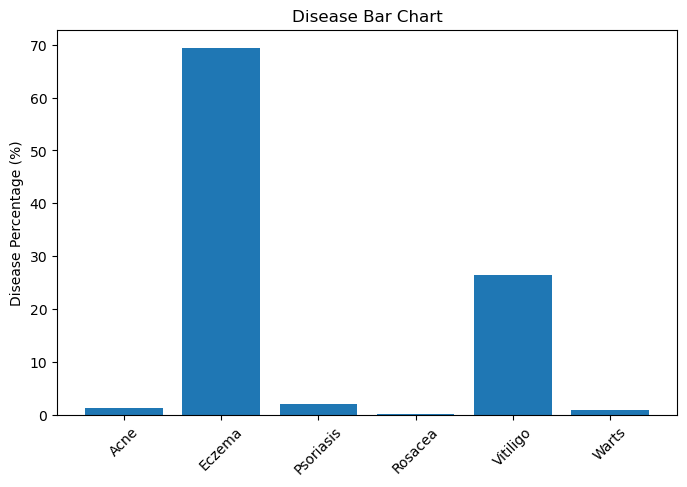

In [42]:
IMG_PATH = r"C:\Users\user\Downloads\diseases\eczema\4.jpg"
IMG_SIZE = 224

# Read image
img = cv2.imread(IMG_PATH)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Preprocess
img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
img_array = img_resized / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
pred = model.predict(img_array)[0]

# Disease percentage
disease_percentages = pred * 100
predicted_index = np.argmax(pred)
predicted_class = class_names[predicted_index]
predicted_percent = disease_percentages[predicted_index]

# ================= IMAGE OUTPUT =================
plt.figure(figsize=(5,6))
plt.imshow(img_rgb)
plt.axis("off")
plt.title(f"{predicted_class} ({predicted_percent:.2f}%)")
plt.show()

# ================= TEXT OUTPUT =================
print("🧬 Detected Disease:", predicted_class)
print(f"🧪 Disease Percentage: {predicted_percent:.2f} %")

print("\n💊 Recommended Treatment:")
for c in recommendations.get(predicted_class, ["Consult Dermatologist"]):
    print("•", c)


# ================= BAR CHART =================
plt.figure(figsize=(8,5))
plt.bar(class_names, disease_percentages)
plt.xticks(rotation=45)
plt.ylabel("Disease Percentage (%)")
plt.title("Disease Bar Chart")
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step


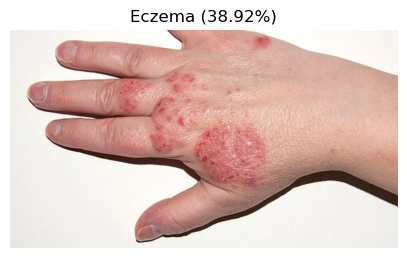

🧬 Detected Disease: Eczema
🧪 Disease Percentage: 38.92 %

💊 Recommended Treatment:
• Moisturizers
• Topical Corticosteroids
• Avoid Allergens
• Consult Dermatologist


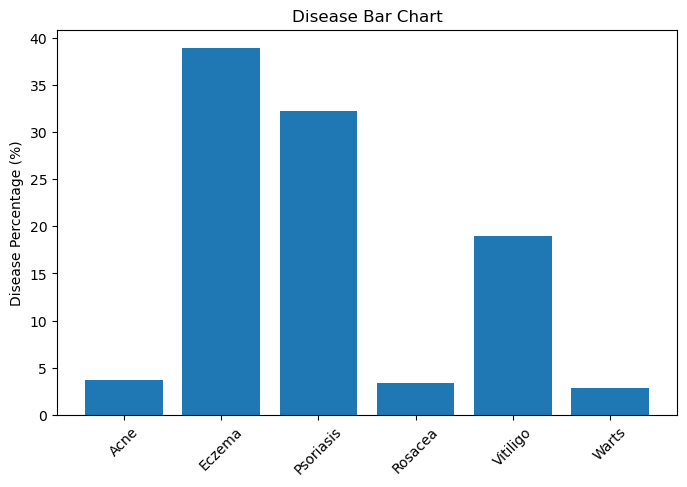

In [43]:
IMG_PATH = r"C:\Users\user\Downloads\diseases\eczema\2.webp"
IMG_SIZE = 224

# Read image
img = cv2.imread(IMG_PATH)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Preprocess
img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
img_array = img_resized / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
pred = model.predict(img_array)[0]

# Disease percentage
disease_percentages = pred * 100
predicted_index = np.argmax(pred)
predicted_class = class_names[predicted_index]
predicted_percent = disease_percentages[predicted_index]

# ================= IMAGE OUTPUT =================
plt.figure(figsize=(5,6))
plt.imshow(img_rgb)
plt.axis("off")
plt.title(f"{predicted_class} ({predicted_percent:.2f}%)")
plt.show()

# ================= TEXT OUTPUT =================
print("🧬 Detected Disease:", predicted_class)
print(f"🧪 Disease Percentage: {predicted_percent:.2f} %")

print("\n💊 Recommended Treatment:")
for c in recommendations.get(predicted_class, ["Consult Dermatologist"]):
    print("•", c)


# ================= BAR CHART =================
plt.figure(figsize=(8,5))
plt.bar(class_names, disease_percentages)
plt.xticks(rotation=45)
plt.ylabel("Disease Percentage (%)")
plt.title("Disease Bar Chart")
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step


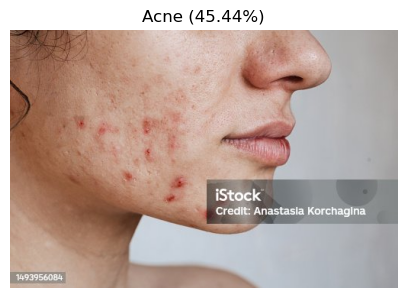

🧬 Detected Disease: Acne
🧪 Disease Percentage: 45.44 %

💊 Recommended Treatment:
• Benzoyl Peroxide
• Salicylic Acid
• Topical Retinoids
• Consult Dermatologist


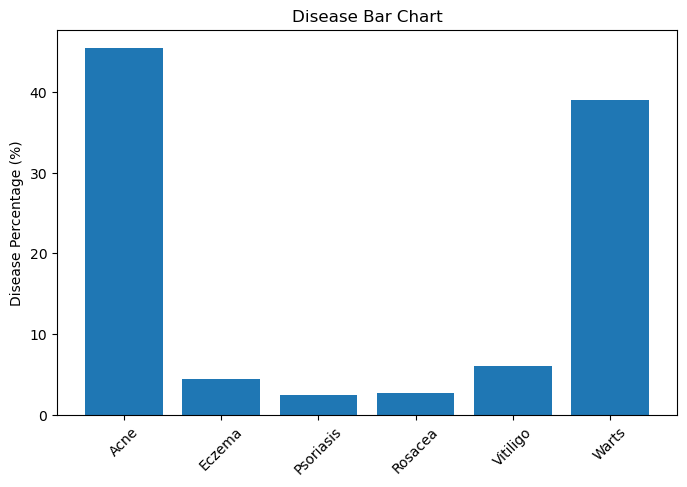

In [46]:
IMG_PATH = r"C:\Users\user\Downloads\diseases\Acne\1.jpg"
IMG_SIZE = 224

# Read image
img = cv2.imread(IMG_PATH)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Preprocess
img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
img_array = img_resized / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
pred = model.predict(img_array)[0]

# Disease percentage
disease_percentages = pred * 100
predicted_index = np.argmax(pred)
predicted_class = class_names[predicted_index]
predicted_percent = disease_percentages[predicted_index]

# ================= IMAGE OUTPUT =================
plt.figure(figsize=(5,6))
plt.imshow(img_rgb)
plt.axis("off")
plt.title(f"{predicted_class} ({predicted_percent:.2f}%)")
plt.show()

# ================= TEXT OUTPUT =================
print("🧬 Detected Disease:", predicted_class)
print(f"🧪 Disease Percentage: {predicted_percent:.2f} %")

print("\n💊 Recommended Treatment:")
for c in recommendations.get(predicted_class, ["Consult Dermatologist"]):
    print("•", c)


# ================= BAR CHART =================
plt.figure(figsize=(8,5))
plt.bar(class_names, disease_percentages)
plt.xticks(rotation=45)
plt.ylabel("Disease Percentage (%)")
plt.title("Disease Bar Chart")
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step


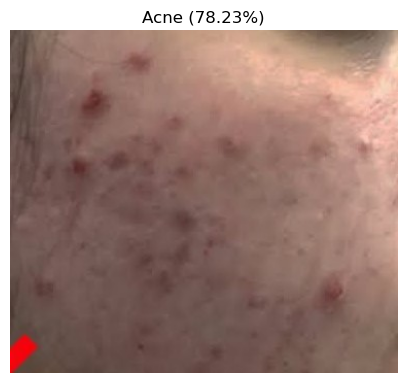

🧬 Detected Disease: Acne
🧪 Disease Percentage: 78.23 %

💊 Recommended Treatment:
• Benzoyl Peroxide
• Salicylic Acid
• Topical Retinoids
• Consult Dermatologist


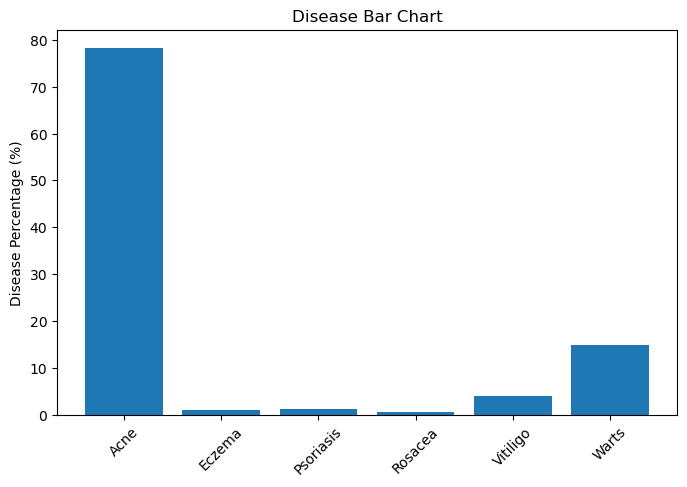

In [50]:
IMG_PATH = r"C:\Users\user\Downloads\diseases\Acne\5.jpg"
IMG_SIZE = 224

# Read image
img = cv2.imread(IMG_PATH)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Preprocess
img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
img_array = img_resized / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
pred = model.predict(img_array)[0]

# Disease percentage
disease_percentages = pred * 100
predicted_index = np.argmax(pred)
predicted_class = class_names[predicted_index]
predicted_percent = disease_percentages[predicted_index]

# ================= IMAGE OUTPUT =================
plt.figure(figsize=(5,6))
plt.imshow(img_rgb)
plt.axis("off")
plt.title(f"{predicted_class} ({predicted_percent:.2f}%)")
plt.show()

# ================= TEXT OUTPUT =================
print("🧬 Detected Disease:", predicted_class)
print(f"🧪 Disease Percentage: {predicted_percent:.2f} %")

print("\n💊 Recommended Treatment:")
for c in recommendations.get(predicted_class, ["Consult Dermatologist"]):
    print("•", c)


# ================= BAR CHART =================
plt.figure(figsize=(8,5))
plt.bar(class_names, disease_percentages)
plt.xticks(rotation=45)
plt.ylabel("Disease Percentage (%)")
plt.title("Disease Bar Chart")
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step


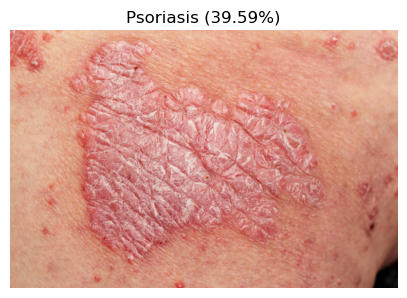

🧬 Detected Disease: Psoriasis
🧪 Disease Percentage: 39.59 %

💊 Recommended Treatment:
• Topical Corticosteroids
• Vitamin D Analogues
• Phototherapy
• Consult Dermatologist


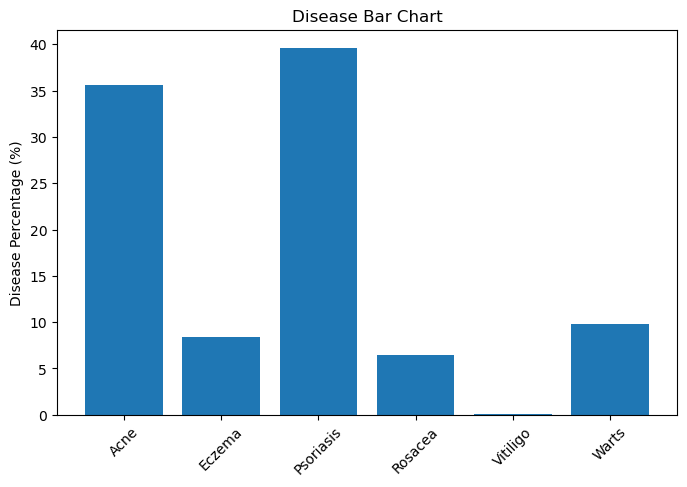

In [51]:
IMG_PATH = r"C:\Users\user\Downloads\diseases\Psorasis\1.jpg"
IMG_SIZE = 224

# Read image
img = cv2.imread(IMG_PATH)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Preprocess
img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
img_array = img_resized / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
pred = model.predict(img_array)[0]

# Disease percentage
disease_percentages = pred * 100
predicted_index = np.argmax(pred)
predicted_class = class_names[predicted_index]
predicted_percent = disease_percentages[predicted_index]

# ================= IMAGE OUTPUT =================
plt.figure(figsize=(5,6))
plt.imshow(img_rgb)
plt.axis("off")
plt.title(f"{predicted_class} ({predicted_percent:.2f}%)")
plt.show()

# ================= TEXT OUTPUT =================
print("🧬 Detected Disease:", predicted_class)
print(f"🧪 Disease Percentage: {predicted_percent:.2f} %")

print("\n💊 Recommended Treatment:")
for c in recommendations.get(predicted_class, ["Consult Dermatologist"]):
    print("•", c)


# ================= BAR CHART =================
plt.figure(figsize=(8,5))
plt.bar(class_names, disease_percentages)
plt.xticks(rotation=45)
plt.ylabel("Disease Percentage (%)")
plt.title("Disease Bar Chart")
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step


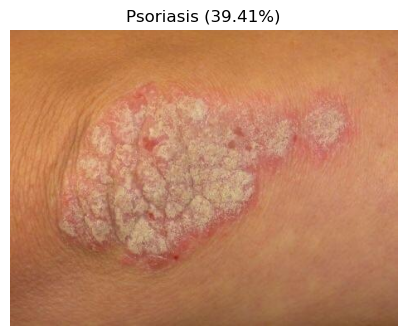

🧬 Detected Disease: Psoriasis
🧪 Disease Percentage: 39.41 %

💊 Recommended Treatment:
• Topical Corticosteroids
• Vitamin D Analogues
• Phototherapy
• Consult Dermatologist


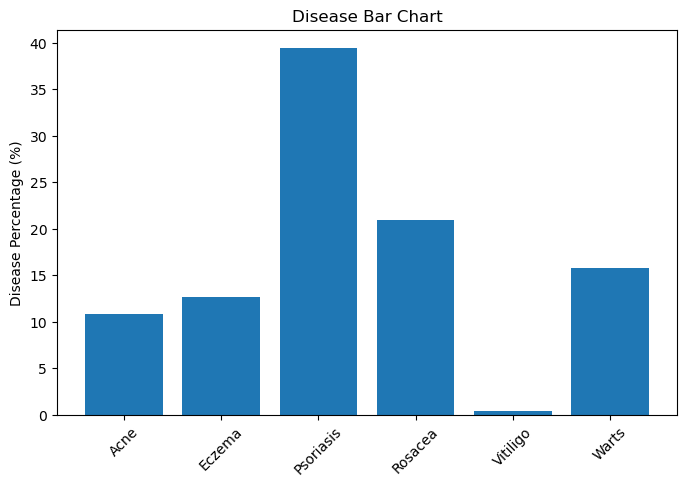

In [53]:
IMG_PATH = r"C:\Users\user\Downloads\diseases\Psorasis\4.jpg"
IMG_SIZE = 224

# Read image
img = cv2.imread(IMG_PATH)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Preprocess
img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
img_array = img_resized / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
pred = model.predict(img_array)[0]

# Disease percentage
disease_percentages = pred * 100
predicted_index = np.argmax(pred)
predicted_class = class_names[predicted_index]
predicted_percent = disease_percentages[predicted_index]

# ================= IMAGE OUTPUT =================
plt.figure(figsize=(5,6))
plt.imshow(img_rgb)
plt.axis("off")
plt.title(f"{predicted_class} ({predicted_percent:.2f}%)")
plt.show()

# ================= TEXT OUTPUT =================
print("🧬 Detected Disease:", predicted_class)
print(f"🧪 Disease Percentage: {predicted_percent:.2f} %")

print("\n💊 Recommended Treatment:")
for c in recommendations.get(predicted_class, ["Consult Dermatologist"]):
    print("•", c)


# ================= BAR CHART =================
plt.figure(figsize=(8,5))
plt.bar(class_names, disease_percentages)
plt.xticks(rotation=45)
plt.ylabel("Disease Percentage (%)")
plt.title("Disease Bar Chart")
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step


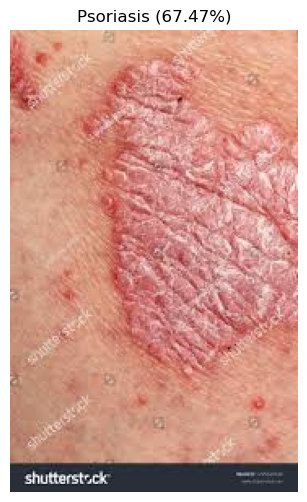

🧬 Detected Disease: Psoriasis
🧪 Disease Percentage: 67.47 %

💊 Recommended Treatment:
• Topical Corticosteroids
• Vitamin D Analogues
• Phototherapy
• Consult Dermatologist


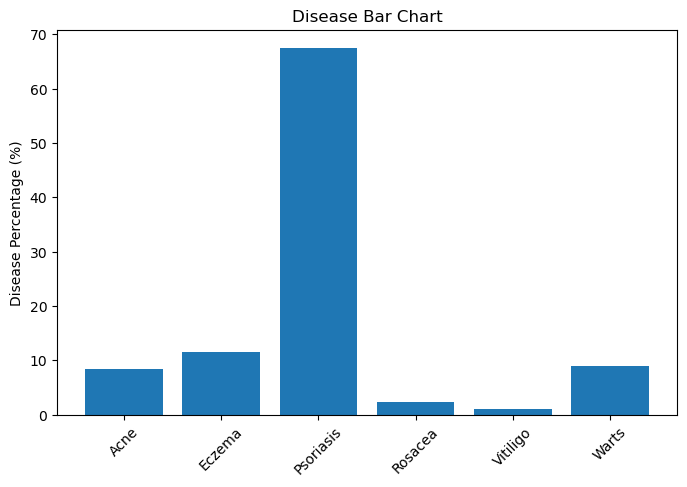

In [54]:
IMG_PATH = r"C:\Users\user\Downloads\diseases\Psorasis\5.jpeg"
IMG_SIZE = 224

# Read image
img = cv2.imread(IMG_PATH)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Preprocess
img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
img_array = img_resized / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
pred = model.predict(img_array)[0]

# Disease percentage
disease_percentages = pred * 100
predicted_index = np.argmax(pred)
predicted_class = class_names[predicted_index]
predicted_percent = disease_percentages[predicted_index]

# ================= IMAGE OUTPUT =================
plt.figure(figsize=(5,6))
plt.imshow(img_rgb)
plt.axis("off")
plt.title(f"{predicted_class} ({predicted_percent:.2f}%)")
plt.show()

# ================= TEXT OUTPUT =================
print("🧬 Detected Disease:", predicted_class)
print(f"🧪 Disease Percentage: {predicted_percent:.2f} %")

print("\n💊 Recommended Treatment:")
for c in recommendations.get(predicted_class, ["Consult Dermatologist"]):
    print("•", c)


# ================= BAR CHART =================
plt.figure(figsize=(8,5))
plt.bar(class_names, disease_percentages)
plt.xticks(rotation=45)
plt.ylabel("Disease Percentage (%)")
plt.title("Disease Bar Chart")
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step


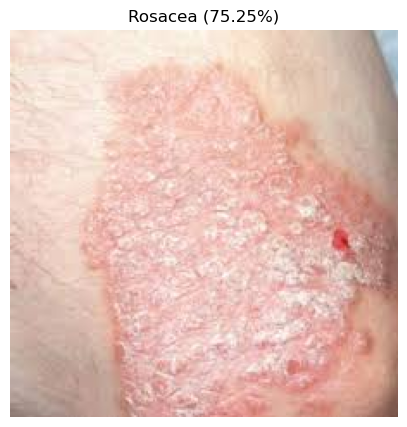

🧬 Detected Disease: Rosacea
🧪 Disease Percentage: 75.25 %

💊 Recommended Treatment:
• Metronidazole Cream
• Azelaic Acid
• Sun Protection
• Consult Dermatologist


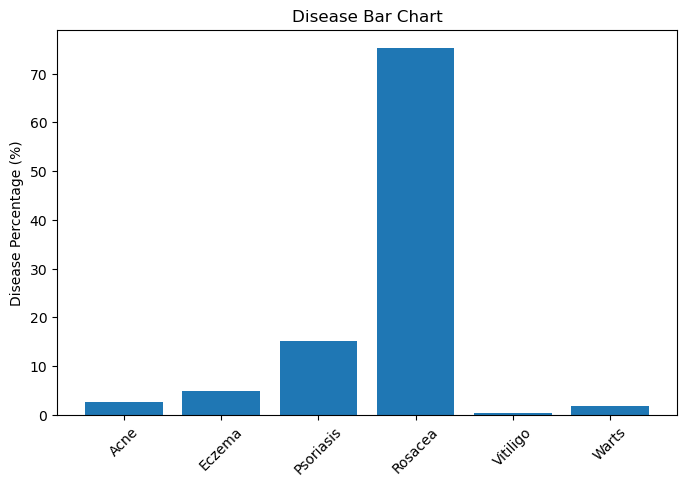

In [55]:
IMG_PATH = r"C:\Users\user\Downloads\diseases\Rosacea\1.jpeg"
IMG_SIZE = 224

# Read image
img = cv2.imread(IMG_PATH)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Preprocess
img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
img_array = img_resized / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
pred = model.predict(img_array)[0]

# Disease percentage
disease_percentages = pred * 100
predicted_index = np.argmax(pred)
predicted_class = class_names[predicted_index]
predicted_percent = disease_percentages[predicted_index]

# ================= IMAGE OUTPUT =================
plt.figure(figsize=(5,6))
plt.imshow(img_rgb)
plt.axis("off")
plt.title(f"{predicted_class} ({predicted_percent:.2f}%)")
plt.show()

# ================= TEXT OUTPUT =================
print("🧬 Detected Disease:", predicted_class)
print(f"🧪 Disease Percentage: {predicted_percent:.2f} %")

print("\n💊 Recommended Treatment:")
for c in recommendations.get(predicted_class, ["Consult Dermatologist"]):
    print("•", c)


# ================= BAR CHART =================
plt.figure(figsize=(8,5))
plt.bar(class_names, disease_percentages)
plt.xticks(rotation=45)
plt.ylabel("Disease Percentage (%)")
plt.title("Disease Bar Chart")
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step


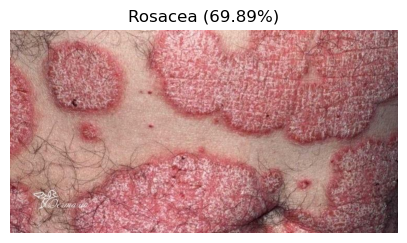

🧬 Detected Disease: Rosacea
🧪 Disease Percentage: 69.89 %

💊 Recommended Treatment:
• Metronidazole Cream
• Azelaic Acid
• Sun Protection
• Consult Dermatologist


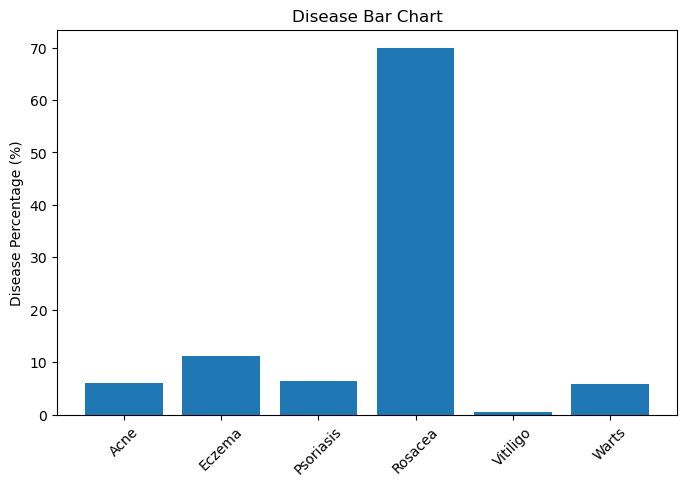

In [56]:
IMG_PATH = r"C:\Users\user\Downloads\diseases\Rosacea\1.jpg"
IMG_SIZE = 224

# Read image
img = cv2.imread(IMG_PATH)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Preprocess
img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
img_array = img_resized / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
pred = model.predict(img_array)[0]

# Disease percentage
disease_percentages = pred * 100
predicted_index = np.argmax(pred)
predicted_class = class_names[predicted_index]
predicted_percent = disease_percentages[predicted_index]

# ================= IMAGE OUTPUT =================
plt.figure(figsize=(5,6))
plt.imshow(img_rgb)
plt.axis("off")
plt.title(f"{predicted_class} ({predicted_percent:.2f}%)")
plt.show()

# ================= TEXT OUTPUT =================
print("🧬 Detected Disease:", predicted_class)
print(f"🧪 Disease Percentage: {predicted_percent:.2f} %")

print("\n💊 Recommended Treatment:")
for c in recommendations.get(predicted_class, ["Consult Dermatologist"]):
    print("•", c)


# ================= BAR CHART =================
plt.figure(figsize=(8,5))
plt.bar(class_names, disease_percentages)
plt.xticks(rotation=45)
plt.ylabel("Disease Percentage (%)")
plt.title("Disease Bar Chart")
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step


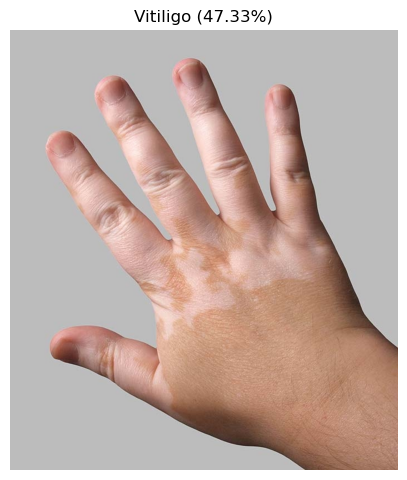

🧬 Detected Disease: Vitiligo
🧪 Disease Percentage: 47.33 %

💊 Recommended Treatment:
• Topical Corticosteroids
• Phototherapy
• Consult Dermatologist


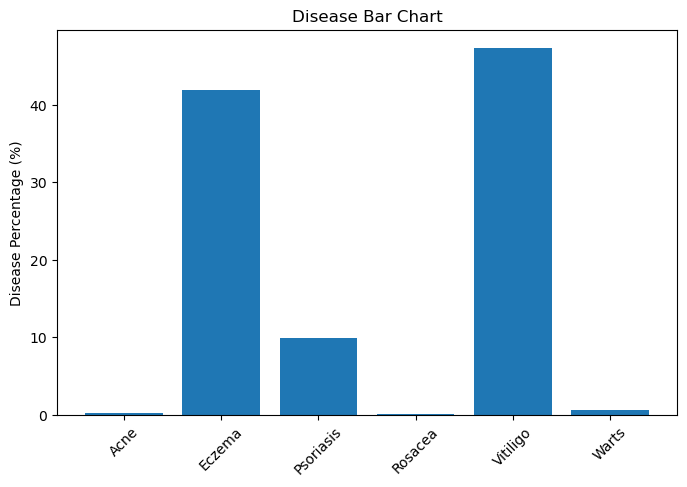

In [57]:
IMG_PATH = r"C:\Users\user\Downloads\diseases\Vitiligo\1.jpg"
IMG_SIZE = 224

# Read image
img = cv2.imread(IMG_PATH)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Preprocess
img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
img_array = img_resized / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
pred = model.predict(img_array)[0]

# Disease percentage
disease_percentages = pred * 100
predicted_index = np.argmax(pred)
predicted_class = class_names[predicted_index]
predicted_percent = disease_percentages[predicted_index]

# ================= IMAGE OUTPUT =================
plt.figure(figsize=(5,6))
plt.imshow(img_rgb)
plt.axis("off")
plt.title(f"{predicted_class} ({predicted_percent:.2f}%)")
plt.show()

# ================= TEXT OUTPUT =================
print("🧬 Detected Disease:", predicted_class)
print(f"🧪 Disease Percentage: {predicted_percent:.2f} %")

print("\n💊 Recommended Treatment:")
for c in recommendations.get(predicted_class, ["Consult Dermatologist"]):
    print("•", c)


# ================= BAR CHART =================
plt.figure(figsize=(8,5))
plt.bar(class_names, disease_percentages)
plt.xticks(rotation=45)
plt.ylabel("Disease Percentage (%)")
plt.title("Disease Bar Chart")
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step


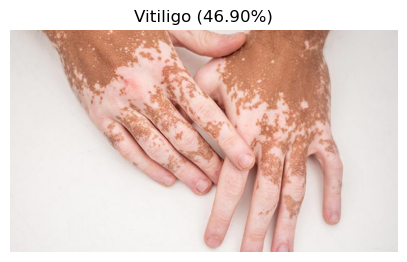

🧬 Detected Disease: Vitiligo
🧪 Disease Percentage: 46.90 %

💊 Recommended Treatment:
• Topical Corticosteroids
• Phototherapy
• Consult Dermatologist


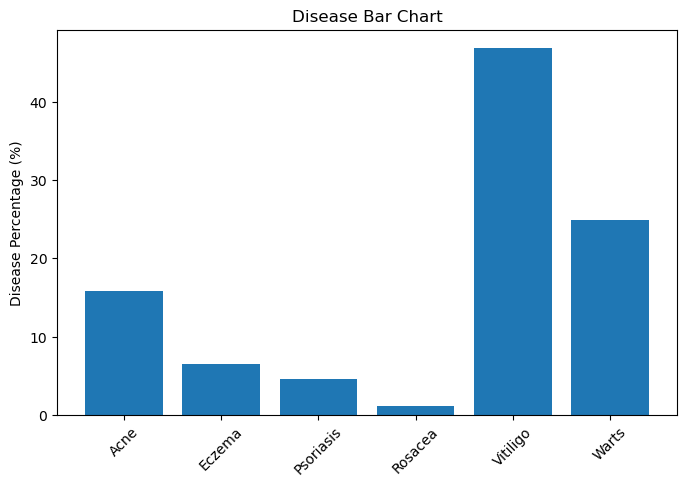

In [58]:
IMG_PATH = r"C:\Users\user\Downloads\diseases\Vitiligo\2.jpg"
IMG_SIZE = 224

# Read image
img = cv2.imread(IMG_PATH)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Preprocess
img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
img_array = img_resized / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
pred = model.predict(img_array)[0]

# Disease percentage
disease_percentages = pred * 100
predicted_index = np.argmax(pred)
predicted_class = class_names[predicted_index]
predicted_percent = disease_percentages[predicted_index]

# ================= IMAGE OUTPUT =================
plt.figure(figsize=(5,6))
plt.imshow(img_rgb)
plt.axis("off")
plt.title(f"{predicted_class} ({predicted_percent:.2f}%)")
plt.show()

# ================= TEXT OUTPUT =================
print("🧬 Detected Disease:", predicted_class)
print(f"🧪 Disease Percentage: {predicted_percent:.2f} %")

print("\n💊 Recommended Treatment:")
for c in recommendations.get(predicted_class, ["Consult Dermatologist"]):
    print("•", c)


# ================= BAR CHART =================
plt.figure(figsize=(8,5))
plt.bar(class_names, disease_percentages)
plt.xticks(rotation=45)
plt.ylabel("Disease Percentage (%)")
plt.title("Disease Bar Chart")
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step


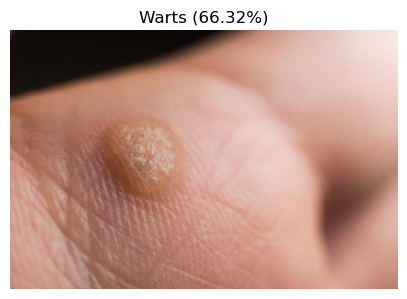

🧬 Detected Disease: Warts
🧪 Disease Percentage: 66.32 %

💊 Recommended Treatment:
• Salicylic Acid
• Cryotherapy
• Consult Dermatologist


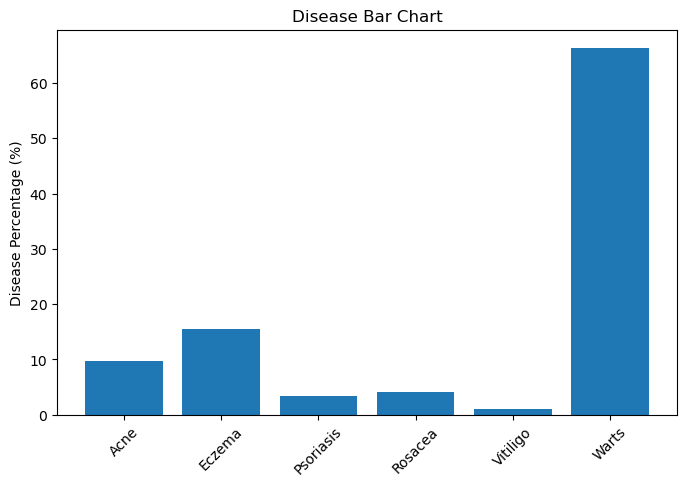

In [59]:
IMG_PATH = r"C:\Users\user\Downloads\diseases\Warts\2.jpeg"
IMG_SIZE = 224

# Read image
img = cv2.imread(IMG_PATH)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Preprocess
img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
img_array = img_resized / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
pred = model.predict(img_array)[0]

# Disease percentage
disease_percentages = pred * 100
predicted_index = np.argmax(pred)
predicted_class = class_names[predicted_index]
predicted_percent = disease_percentages[predicted_index]

# ================= IMAGE OUTPUT =================
plt.figure(figsize=(5,6))
plt.imshow(img_rgb)
plt.axis("off")
plt.title(f"{predicted_class} ({predicted_percent:.2f}%)")
plt.show()

# ================= TEXT OUTPUT =================
print("🧬 Detected Disease:", predicted_class)
print(f"🧪 Disease Percentage: {predicted_percent:.2f} %")

print("\n💊 Recommended Treatment:")
for c in recommendations.get(predicted_class, ["Consult Dermatologist"]):
    print("•", c)


# ================= BAR CHART =================
plt.figure(figsize=(8,5))
plt.bar(class_names, disease_percentages)
plt.xticks(rotation=45)
plt.ylabel("Disease Percentage (%)")
plt.title("Disease Bar Chart")
plt.show()


In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import load_model


In [3]:
MODEL_PATH = r"C:\Users\user\Desktop\Skin Detector\archive\models\skin_detector_best_6cls.keras"
model = load_model(MODEL_PATH)
print("✅ Model loaded")


✅ Model loaded


In [4]:
class_names = [
    "Acne",
    "Eczema",
    "Psoriasis",
    "Rosacea",
    "Vitiligo",
    "Warts"
]


In [5]:
recommendations = {
    "Acne": ["Benzoyl Peroxide", "Salicylic Acid"],
    "Eczema": ["Moisturizer", "Topical Steroids"],
    "Psoriasis": ["Vitamin D analogues", "Phototherapy"],
    "Rosacea": ["Azelaic Acid", "Avoid triggers"],
    "Vitiligo": ["Topical Corticosteroids", "Phototherapy"],
    "Warts": ["Salicylic Acid", "Cryotherapy"]
}


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step


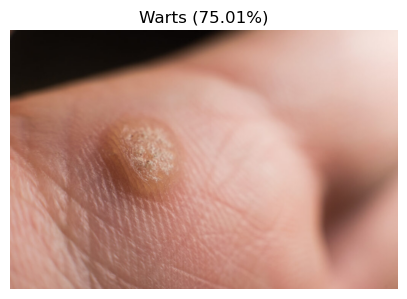

🧬 Detected Disease: Warts
🧪 Disease Percentage: 75.01 %

💊 Recommended Treatment:
• Salicylic Acid
• Cryotherapy


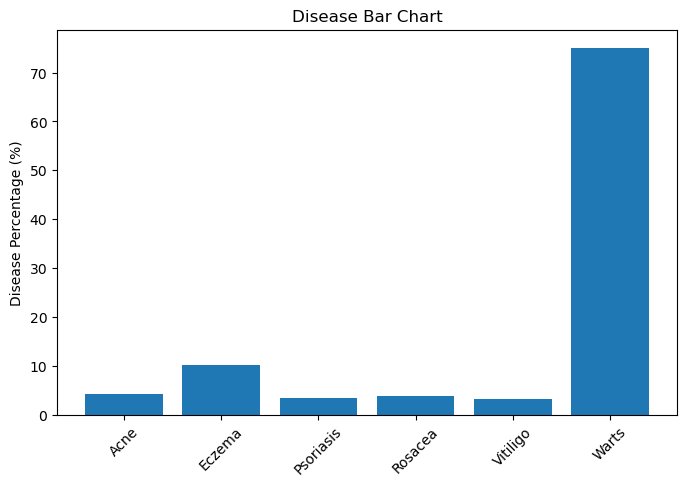

In [8]:
IMG_PATH = r"C:\Users\user\Downloads\diseases\Warts\2.jpeg"
IMG_SIZE = 224

# Read image
img = cv2.imread(IMG_PATH)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Preprocess
img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
img_array = img_resized / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
pred = model.predict(img_array)[0]

# Disease percentage
disease_percentages = pred * 100
predicted_index = np.argmax(pred)
predicted_class = class_names[predicted_index]
predicted_percent = disease_percentages[predicted_index]

# ================= IMAGE OUTPUT =================
plt.figure(figsize=(5,6))
plt.imshow(img_rgb)
plt.axis("off")
plt.title(f"{predicted_class} ({predicted_percent:.2f}%)")
plt.show()

# ================= TEXT OUTPUT =================
print("🧬 Detected Disease:", predicted_class)
print(f"🧪 Disease Percentage: {predicted_percent:.2f} %")

print("\n💊 Recommended Treatment:")
for c in recommendations.get(predicted_class, ["Consult Dermatologist"]):
    print("•", c)


# ================= BAR CHART =================
plt.figure(figsize=(8,5))
plt.bar(class_names, disease_percentages)
plt.xticks(rotation=45)
plt.ylabel("Disease Percentage (%)")
plt.title("Disease Bar Chart")
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step


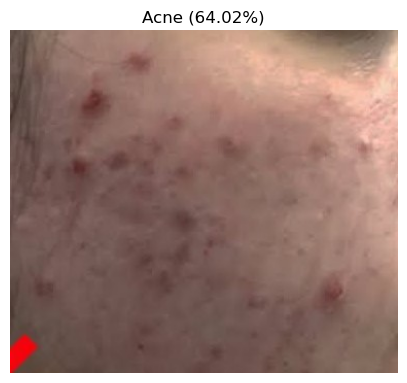

🧬 Detected Disease: Acne
🧪 Disease Percentage: 64.02 %

💊 Recommended Treatment:
• Benzoyl Peroxide
• Salicylic Acid


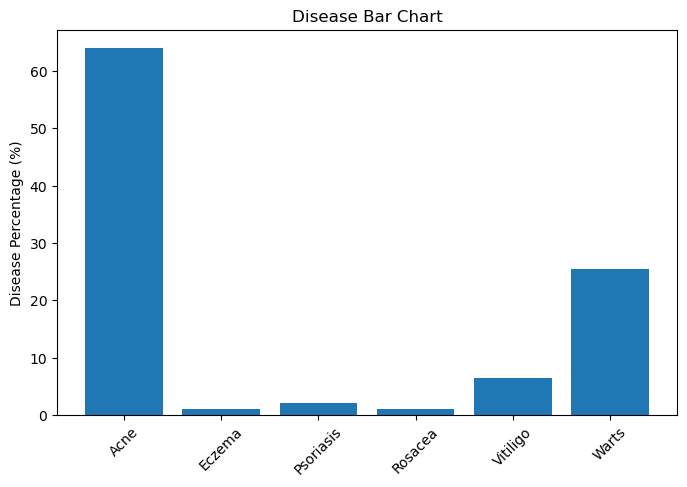

In [13]:
IMG_PATH = r"C:\Users\user\Downloads\diseases\Acne\5.jpg"
IMG_SIZE = 224

# Read image
img = cv2.imread(IMG_PATH)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Preprocess
img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
img_array = img_resized / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
pred = model.predict(img_array)[0]

# Disease percentage
disease_percentages = pred * 100
predicted_index = np.argmax(pred)
predicted_class = class_names[predicted_index]
predicted_percent = disease_percentages[predicted_index]

# ================= IMAGE OUTPUT =================
plt.figure(figsize=(5,6))
plt.imshow(img_rgb)
plt.axis("off")
plt.title(f"{predicted_class} ({predicted_percent:.2f}%)")
plt.show()

# ================= TEXT OUTPUT =================
print("🧬 Detected Disease:", predicted_class)
print(f"🧪 Disease Percentage: {predicted_percent:.2f} %")

print("\n💊 Recommended Treatment:")
for c in recommendations.get(predicted_class, ["Consult Dermatologist"]):
    print("•", c)


# ================= BAR CHART =================
plt.figure(figsize=(8,5))
plt.bar(class_names, disease_percentages)
plt.xticks(rotation=45)
plt.ylabel("Disease Percentage (%)")
plt.title("Disease Bar Chart")
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step


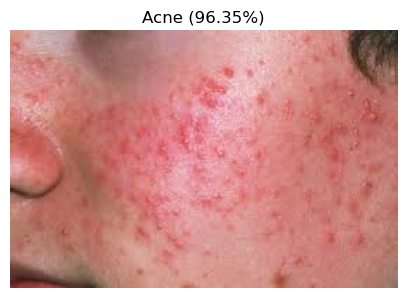

🧬 Detected Disease: Acne
🧪 Disease Percentage: 96.35 %

💊 Recommended Treatment:
• Benzoyl Peroxide
• Salicylic Acid


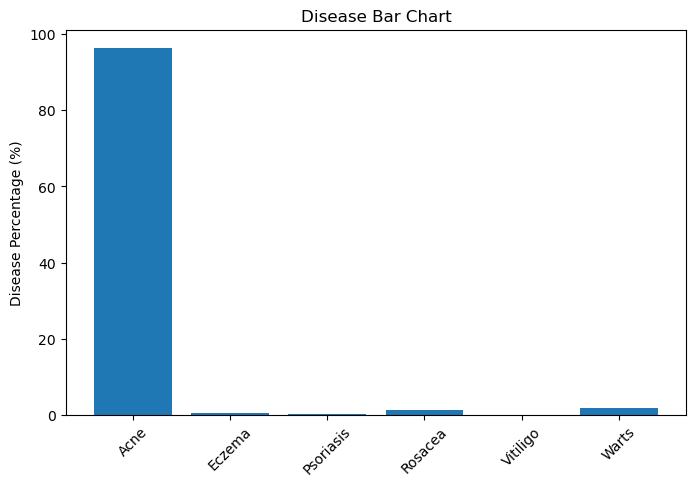

In [15]:
IMG_PATH = r"C:\Users\user\Downloads\diseases\Acne\6.jpeg"
IMG_SIZE = 224

# Read image
img = cv2.imread(IMG_PATH)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Preprocess
img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
img_array = img_resized / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
pred = model.predict(img_array)[0]

# Disease percentage
disease_percentages = pred * 100
predicted_index = np.argmax(pred)
predicted_class = class_names[predicted_index]
predicted_percent = disease_percentages[predicted_index]

# ================= IMAGE OUTPUT =================
plt.figure(figsize=(5,6))
plt.imshow(img_rgb)
plt.axis("off")
plt.title(f"{predicted_class} ({predicted_percent:.2f}%)")
plt.show()

# ================= TEXT OUTPUT =================
print("🧬 Detected Disease:", predicted_class)
print(f"🧪 Disease Percentage: {predicted_percent:.2f} %")

print("\n💊 Recommended Treatment:")
for c in recommendations.get(predicted_class, ["Consult Dermatologist"]):
    print("•", c)


# ================= BAR CHART =================
plt.figure(figsize=(8,5))
plt.bar(class_names, disease_percentages)
plt.xticks(rotation=45)
plt.ylabel("Disease Percentage (%)")
plt.title("Disease Bar Chart")
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step


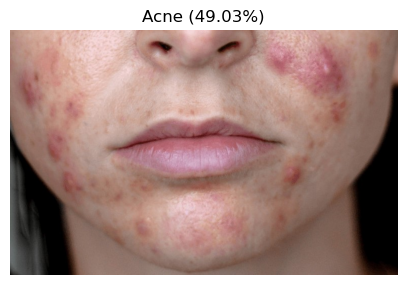

🧬 Detected Disease: Acne
🧪 Disease Percentage: 49.03 %

💊 Recommended Treatment:
• Benzoyl Peroxide
• Salicylic Acid


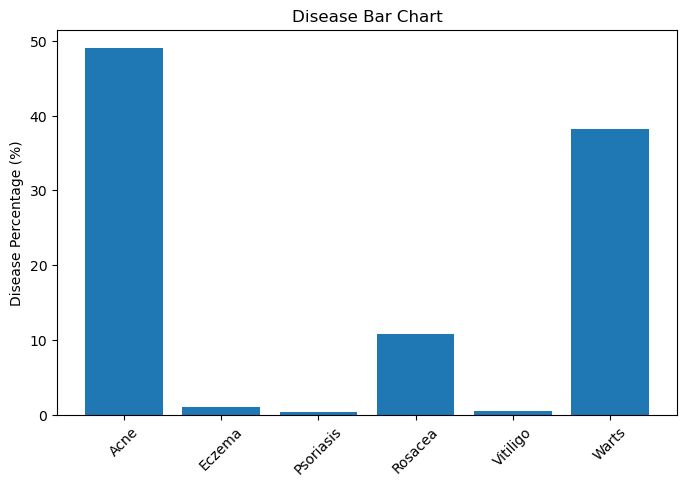

In [17]:
IMG_PATH = r"C:\Users\user\Downloads\diseases\Acne\3.jpg"
IMG_SIZE = 224

# Read image
img = cv2.imread(IMG_PATH)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Preprocess
img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
img_array = img_resized / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
pred = model.predict(img_array)[0]

# Disease percentage
disease_percentages = pred * 100
predicted_index = np.argmax(pred)
predicted_class = class_names[predicted_index]
predicted_percent = disease_percentages[predicted_index]

# ================= IMAGE OUTPUT =================
plt.figure(figsize=(5,6))
plt.imshow(img_rgb)
plt.axis("off")
plt.title(f"{predicted_class} ({predicted_percent:.2f}%)")
plt.show()

# ================= TEXT OUTPUT =================
print("🧬 Detected Disease:", predicted_class)
print(f"🧪 Disease Percentage: {predicted_percent:.2f} %")

print("\n💊 Recommended Treatment:")
for c in recommendations.get(predicted_class, ["Consult Dermatologist"]):
    print("•", c)


# ================= BAR CHART =================
plt.figure(figsize=(8,5))
plt.bar(class_names, disease_percentages)
plt.xticks(rotation=45)
plt.ylabel("Disease Percentage (%)")
plt.title("Disease Bar Chart")
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step


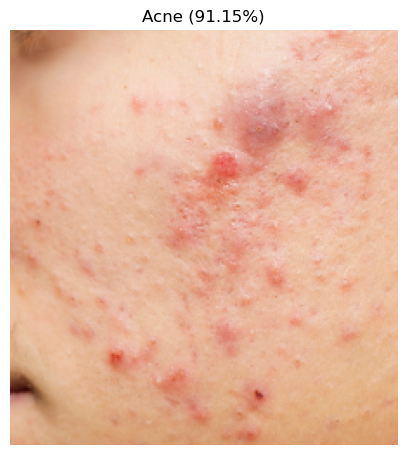

🧬 Detected Disease: Acne
🧪 Disease Percentage: 91.15 %

💊 Recommended Treatment:
• Benzoyl Peroxide
• Salicylic Acid


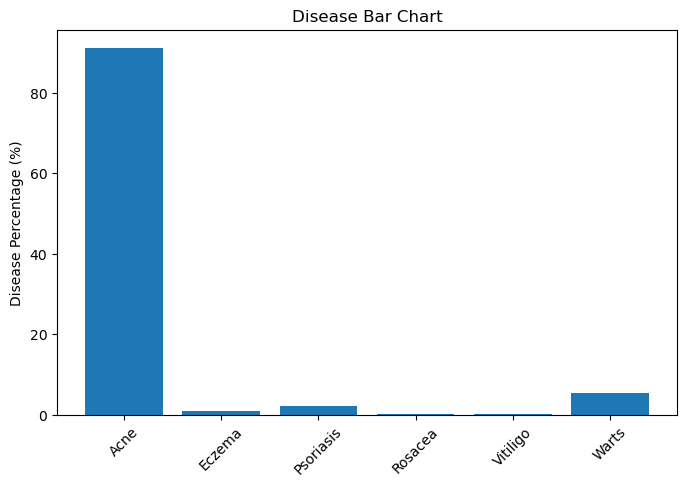

In [18]:
IMG_PATH = r"C:\Users\user\Downloads\diseases\Acne\2.png"
IMG_SIZE = 224

# Read image
img = cv2.imread(IMG_PATH)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Preprocess
img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
img_array = img_resized / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
pred = model.predict(img_array)[0]

# Disease percentage
disease_percentages = pred * 100
predicted_index = np.argmax(pred)
predicted_class = class_names[predicted_index]
predicted_percent = disease_percentages[predicted_index]

# ================= IMAGE OUTPUT =================
plt.figure(figsize=(5,6))
plt.imshow(img_rgb)
plt.axis("off")
plt.title(f"{predicted_class} ({predicted_percent:.2f}%)")
plt.show()

# ================= TEXT OUTPUT =================
print("🧬 Detected Disease:", predicted_class)
print(f"🧪 Disease Percentage: {predicted_percent:.2f} %")

print("\n💊 Recommended Treatment:")
for c in recommendations.get(predicted_class, ["Consult Dermatologist"]):
    print("•", c)


# ================= BAR CHART =================
plt.figure(figsize=(8,5))
plt.bar(class_names, disease_percentages)
plt.xticks(rotation=45)
plt.ylabel("Disease Percentage (%)")
plt.title("Disease Bar Chart")
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step


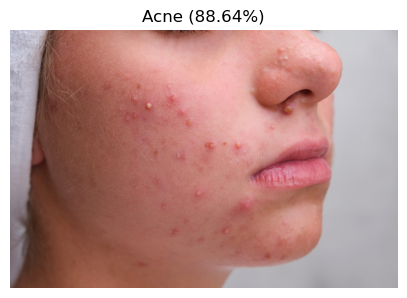

🧬 Detected Disease: Acne
🧪 Disease Percentage: 88.64 %

💊 Recommended Treatment:
• Benzoyl Peroxide
• Salicylic Acid


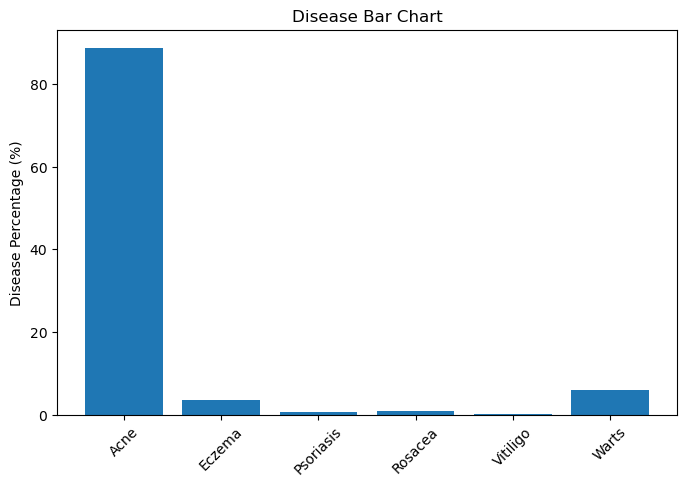

In [19]:
IMG_PATH = r"C:\Users\user\Downloads\diseases\Acne\1.jpg"
IMG_SIZE = 224

# Read image
img = cv2.imread(IMG_PATH)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Preprocess
img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
img_array = img_resized / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
pred = model.predict(img_array)[0]

# Disease percentage
disease_percentages = pred * 100
predicted_index = np.argmax(pred)
predicted_class = class_names[predicted_index]
predicted_percent = disease_percentages[predicted_index]

# ================= IMAGE OUTPUT =================
plt.figure(figsize=(5,6))
plt.imshow(img_rgb)
plt.axis("off")
plt.title(f"{predicted_class} ({predicted_percent:.2f}%)")
plt.show()

# ================= TEXT OUTPUT =================
print("🧬 Detected Disease:", predicted_class)
print(f"🧪 Disease Percentage: {predicted_percent:.2f} %")

print("\n💊 Recommended Treatment:")
for c in recommendations.get(predicted_class, ["Consult Dermatologist"]):
    print("•", c)


# ================= BAR CHART =================
plt.figure(figsize=(8,5))
plt.bar(class_names, disease_percentages)
plt.xticks(rotation=45)
plt.ylabel("Disease Percentage (%)")
plt.title("Disease Bar Chart")
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step


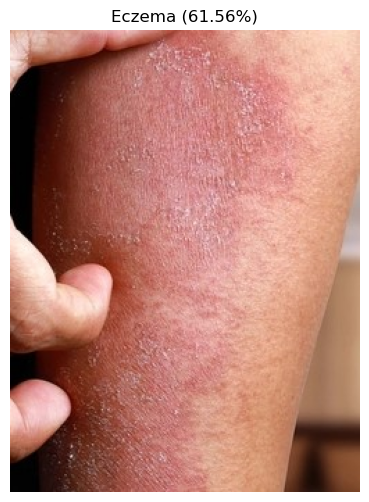

🧬 Detected Disease: Eczema
🧪 Disease Percentage: 61.56 %

💊 Recommended Treatment:
• Moisturizer
• Topical Steroids


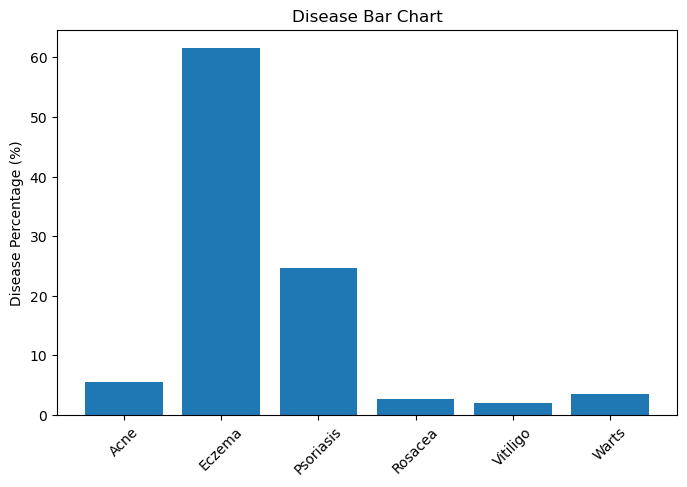

In [26]:
IMG_PATH = r"C:\Users\user\Downloads\diseases\eczema\1.jpg"
IMG_SIZE = 224

# Read image
img = cv2.imread(IMG_PATH)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Preprocess
img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
img_array = img_resized / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
pred = model.predict(img_array)[0]

# Disease percentage
disease_percentages = pred * 100
predicted_index = np.argmax(pred)
predicted_class = class_names[predicted_index]
predicted_percent = disease_percentages[predicted_index]

# ================= IMAGE OUTPUT =================
plt.figure(figsize=(5,6))
plt.imshow(img_rgb)
plt.axis("off")
plt.title(f"{predicted_class} ({predicted_percent:.2f}%)")
plt.show()

# ================= TEXT OUTPUT =================
print("🧬 Detected Disease:", predicted_class)
print(f"🧪 Disease Percentage: {predicted_percent:.2f} %")

print("\n💊 Recommended Treatment:")
for c in recommendations.get(predicted_class, ["Consult Dermatologist"]):
    print("•", c)


# ================= BAR CHART =================
plt.figure(figsize=(8,5))
plt.bar(class_names, disease_percentages)
plt.xticks(rotation=45)
plt.ylabel("Disease Percentage (%)")
plt.title("Disease Bar Chart")
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step


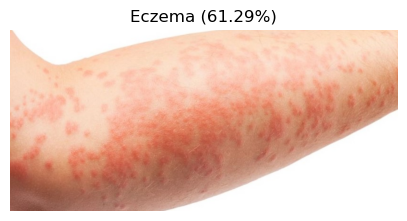

🧬 Detected Disease: Eczema
🧪 Disease Percentage: 61.29 %

💊 Recommended Treatment:
• Moisturizer
• Topical Steroids


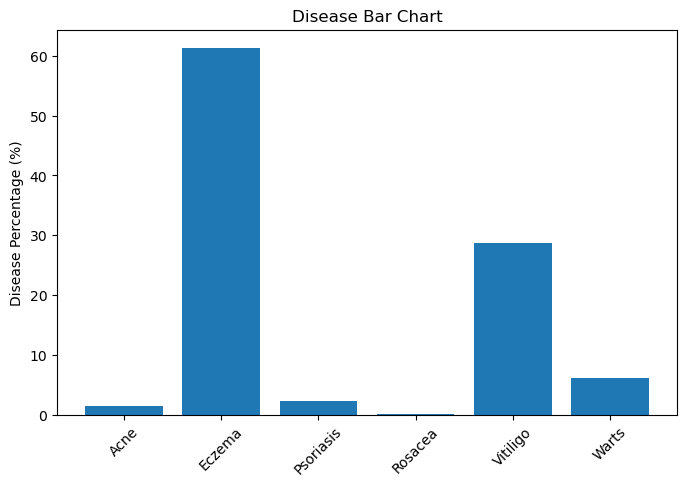

In [28]:
IMG_PATH = r"C:\Users\user\Downloads\diseases\eczema\8.jpg"
IMG_SIZE = 224

# Read image
img = cv2.imread(IMG_PATH)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Preprocess
img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
img_array = img_resized / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
pred = model.predict(img_array)[0]

# Disease percentage
disease_percentages = pred * 100
predicted_index = np.argmax(pred)
predicted_class = class_names[predicted_index]
predicted_percent = disease_percentages[predicted_index]

# ================= IMAGE OUTPUT =================
plt.figure(figsize=(5,6))
plt.imshow(img_rgb)
plt.axis("off")
plt.title(f"{predicted_class} ({predicted_percent:.2f}%)")
plt.show()

# ================= TEXT OUTPUT =================
print("🧬 Detected Disease:", predicted_class)
print(f"🧪 Disease Percentage: {predicted_percent:.2f} %")

print("\n💊 Recommended Treatment:")
for c in recommendations.get(predicted_class, ["Consult Dermatologist"]):
    print("•", c)


# ================= BAR CHART =================
plt.figure(figsize=(8,5))
plt.bar(class_names, disease_percentages)
plt.xticks(rotation=45)
plt.ylabel("Disease Percentage (%)")
plt.title("Disease Bar Chart")
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step


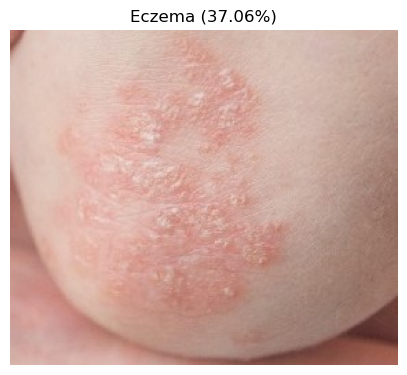

🧬 Detected Disease: Eczema
🧪 Disease Percentage: 37.06 %

💊 Recommended Treatment:
• Moisturizer
• Topical Steroids


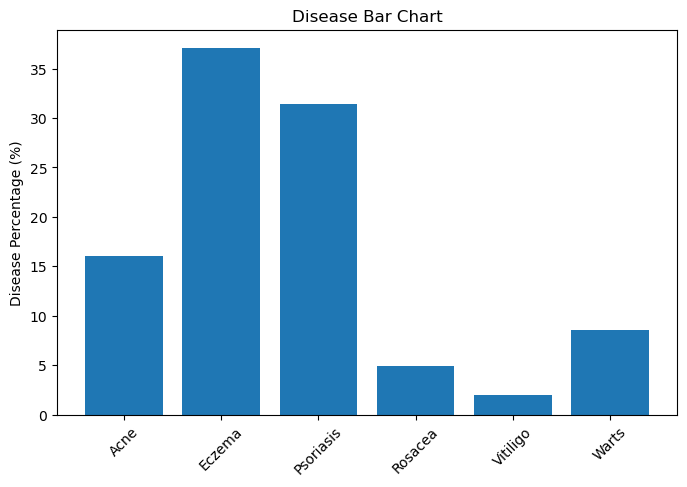

In [29]:
IMG_PATH = r"C:\Users\user\Downloads\diseases\eczema\9.jpeg"
IMG_SIZE = 224

# Read image
img = cv2.imread(IMG_PATH)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Preprocess
img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
img_array = img_resized / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
pred = model.predict(img_array)[0]

# Disease percentage
disease_percentages = pred * 100
predicted_index = np.argmax(pred)
predicted_class = class_names[predicted_index]
predicted_percent = disease_percentages[predicted_index]

# ================= IMAGE OUTPUT =================
plt.figure(figsize=(5,6))
plt.imshow(img_rgb)
plt.axis("off")
plt.title(f"{predicted_class} ({predicted_percent:.2f}%)")
plt.show()

# ================= TEXT OUTPUT =================
print("🧬 Detected Disease:", predicted_class)
print(f"🧪 Disease Percentage: {predicted_percent:.2f} %")

print("\n💊 Recommended Treatment:")
for c in recommendations.get(predicted_class, ["Consult Dermatologist"]):
    print("•", c)


# ================= BAR CHART =================
plt.figure(figsize=(8,5))
plt.bar(class_names, disease_percentages)
plt.xticks(rotation=45)
plt.ylabel("Disease Percentage (%)")
plt.title("Disease Bar Chart")
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step


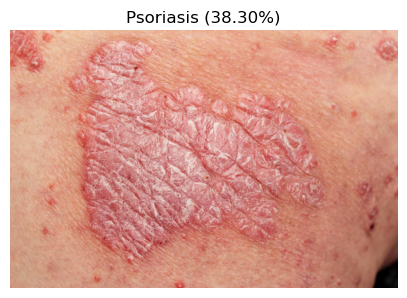

🧬 Detected Disease: Psoriasis
🧪 Disease Percentage: 38.30 %

💊 Recommended Treatment:
• Vitamin D analogues
• Phototherapy


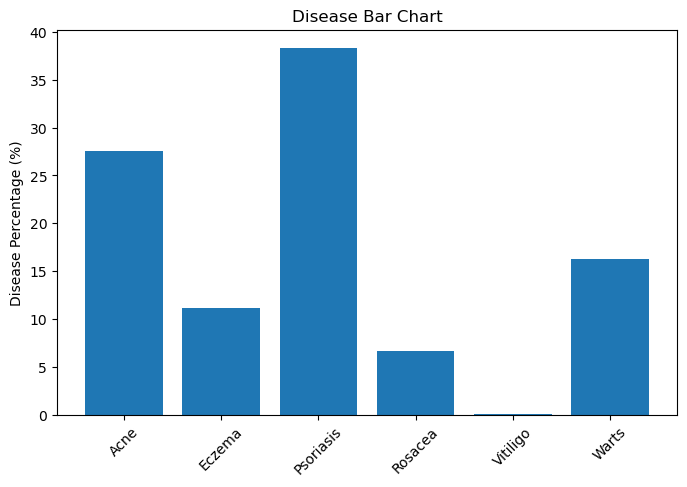

In [32]:
IMG_PATH = r"C:\Users\user\Downloads\diseases\Psorasis\1.jpg"
IMG_SIZE = 224

# Read image
img = cv2.imread(IMG_PATH)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Preprocess
img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
img_array = img_resized / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
pred = model.predict(img_array)[0]

# Disease percentage
disease_percentages = pred * 100
predicted_index = np.argmax(pred)
predicted_class = class_names[predicted_index]
predicted_percent = disease_percentages[predicted_index]

# ================= IMAGE OUTPUT =================
plt.figure(figsize=(5,6))
plt.imshow(img_rgb)
plt.axis("off")
plt.title(f"{predicted_class} ({predicted_percent:.2f}%)")
plt.show()

# ================= TEXT OUTPUT =================
print("🧬 Detected Disease:", predicted_class)
print(f"🧪 Disease Percentage: {predicted_percent:.2f} %")

print("\n💊 Recommended Treatment:")
for c in recommendations.get(predicted_class, ["Consult Dermatologist"]):
    print("•", c)


# ================= BAR CHART =================
plt.figure(figsize=(8,5))
plt.bar(class_names, disease_percentages)
plt.xticks(rotation=45)
plt.ylabel("Disease Percentage (%)")
plt.title("Disease Bar Chart")
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step


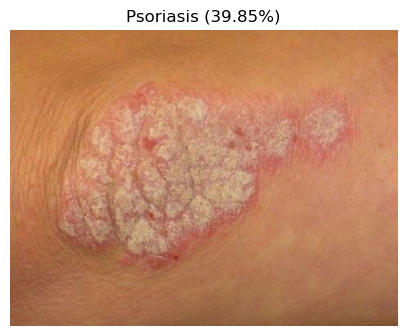

🧬 Detected Disease: Psoriasis
🧪 Disease Percentage: 39.85 %

💊 Recommended Treatment:
• Vitamin D analogues
• Phototherapy


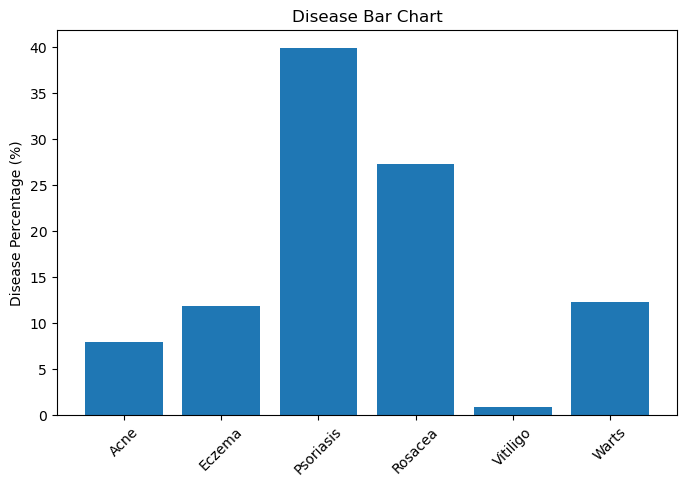

In [33]:
IMG_PATH = r"C:\Users\user\Downloads\diseases\Psorasis\4.jpg"
IMG_SIZE = 224

# Read image
img = cv2.imread(IMG_PATH)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Preprocess
img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
img_array = img_resized / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
pred = model.predict(img_array)[0]

# Disease percentage
disease_percentages = pred * 100
predicted_index = np.argmax(pred)
predicted_class = class_names[predicted_index]
predicted_percent = disease_percentages[predicted_index]

# ================= IMAGE OUTPUT =================
plt.figure(figsize=(5,6))
plt.imshow(img_rgb)
plt.axis("off")
plt.title(f"{predicted_class} ({predicted_percent:.2f}%)")
plt.show()

# ================= TEXT OUTPUT =================
print("🧬 Detected Disease:", predicted_class)
print(f"🧪 Disease Percentage: {predicted_percent:.2f} %")

print("\n💊 Recommended Treatment:")
for c in recommendations.get(predicted_class, ["Consult Dermatologist"]):
    print("•", c)


# ================= BAR CHART =================
plt.figure(figsize=(8,5))
plt.bar(class_names, disease_percentages)
plt.xticks(rotation=45)
plt.ylabel("Disease Percentage (%)")
plt.title("Disease Bar Chart")
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step


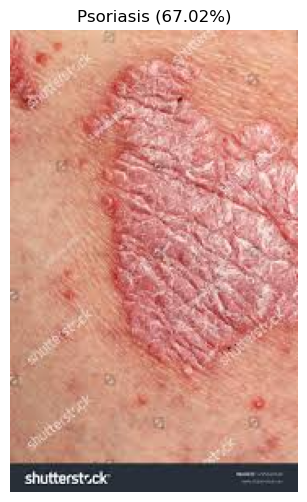

🧬 Detected Disease: Psoriasis
🧪 Disease Percentage: 67.02 %

💊 Recommended Treatment:
• Vitamin D analogues
• Phototherapy


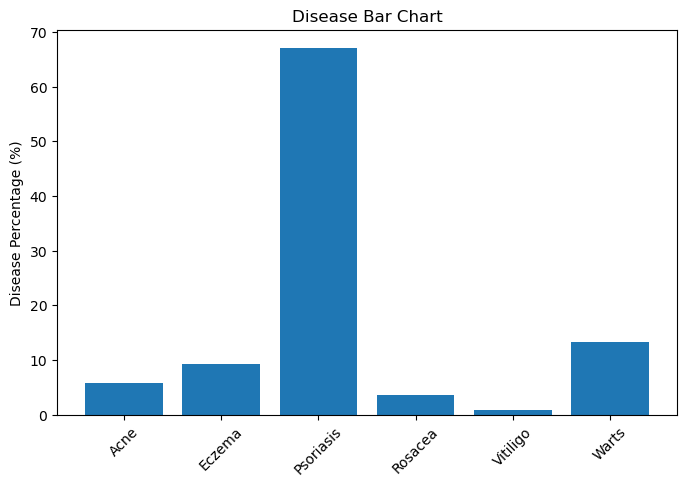

In [34]:
IMG_PATH = r"C:\Users\user\Downloads\diseases\Psorasis\5.jpeg"
IMG_SIZE = 224

# Read image
img = cv2.imread(IMG_PATH)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Preprocess
img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
img_array = img_resized / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
pred = model.predict(img_array)[0]

# Disease percentage
disease_percentages = pred * 100
predicted_index = np.argmax(pred)
predicted_class = class_names[predicted_index]
predicted_percent = disease_percentages[predicted_index]

# ================= IMAGE OUTPUT =================
plt.figure(figsize=(5,6))
plt.imshow(img_rgb)
plt.axis("off")
plt.title(f"{predicted_class} ({predicted_percent:.2f}%)")
plt.show()

# ================= TEXT OUTPUT =================
print("🧬 Detected Disease:", predicted_class)
print(f"🧪 Disease Percentage: {predicted_percent:.2f} %")

print("\n💊 Recommended Treatment:")
for c in recommendations.get(predicted_class, ["Consult Dermatologist"]):
    print("•", c)


# ================= BAR CHART =================
plt.figure(figsize=(8,5))
plt.bar(class_names, disease_percentages)
plt.xticks(rotation=45)
plt.ylabel("Disease Percentage (%)")
plt.title("Disease Bar Chart")
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step


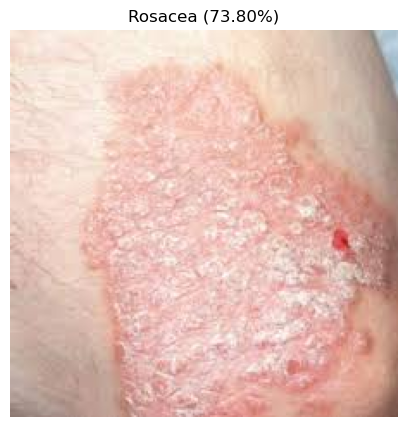

🧬 Detected Disease: Rosacea
🧪 Disease Percentage: 73.80 %

💊 Recommended Treatment:
• Azelaic Acid
• Avoid triggers


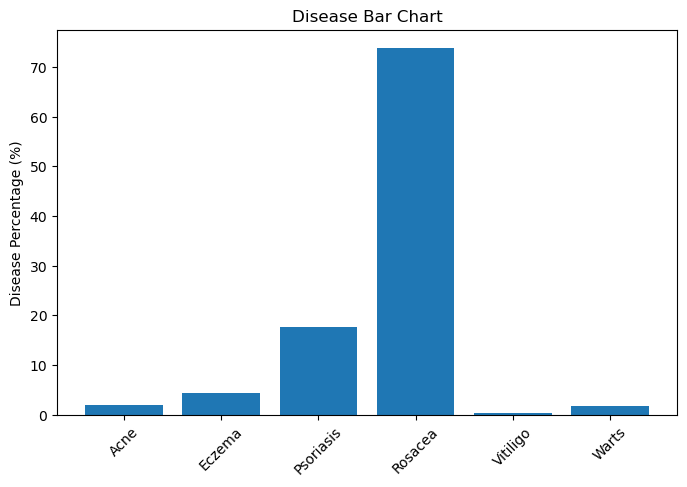

In [35]:
IMG_PATH = r"C:\Users\user\Downloads\diseases\Rosacea\1.jpeg"
IMG_SIZE = 224

# Read image
img = cv2.imread(IMG_PATH)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Preprocess
img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
img_array = img_resized / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
pred = model.predict(img_array)[0]

# Disease percentage
disease_percentages = pred * 100
predicted_index = np.argmax(pred)
predicted_class = class_names[predicted_index]
predicted_percent = disease_percentages[predicted_index]

# ================= IMAGE OUTPUT =================
plt.figure(figsize=(5,6))
plt.imshow(img_rgb)
plt.axis("off")
plt.title(f"{predicted_class} ({predicted_percent:.2f}%)")
plt.show()

# ================= TEXT OUTPUT =================
print("🧬 Detected Disease:", predicted_class)
print(f"🧪 Disease Percentage: {predicted_percent:.2f} %")

print("\n💊 Recommended Treatment:")
for c in recommendations.get(predicted_class, ["Consult Dermatologist"]):
    print("•", c)


# ================= BAR CHART =================
plt.figure(figsize=(8,5))
plt.bar(class_names, disease_percentages)
plt.xticks(rotation=45)
plt.ylabel("Disease Percentage (%)")
plt.title("Disease Bar Chart")
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step


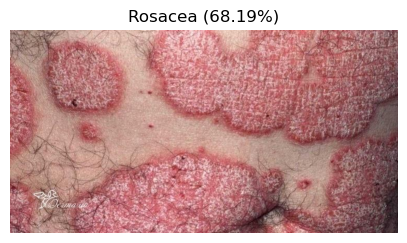

🧬 Detected Disease: Rosacea
🧪 Disease Percentage: 68.19 %

💊 Recommended Treatment:
• Azelaic Acid
• Avoid triggers


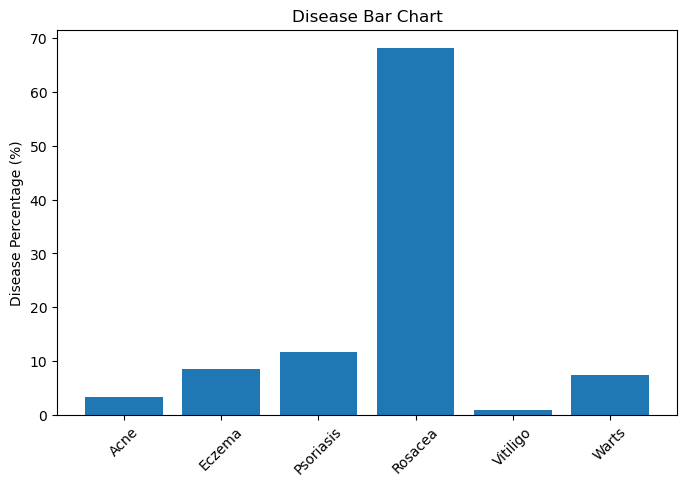

In [36]:
IMG_PATH = r"C:\Users\user\Downloads\diseases\Rosacea\1.jpg"
IMG_SIZE = 224

# Read image
img = cv2.imread(IMG_PATH)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Preprocess
img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
img_array = img_resized / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
pred = model.predict(img_array)[0]

# Disease percentage
disease_percentages = pred * 100
predicted_index = np.argmax(pred)
predicted_class = class_names[predicted_index]
predicted_percent = disease_percentages[predicted_index]

# ================= IMAGE OUTPUT =================
plt.figure(figsize=(5,6))
plt.imshow(img_rgb)
plt.axis("off")
plt.title(f"{predicted_class} ({predicted_percent:.2f}%)")
plt.show()

# ================= TEXT OUTPUT =================
print("🧬 Detected Disease:", predicted_class)
print(f"🧪 Disease Percentage: {predicted_percent:.2f} %")

print("\n💊 Recommended Treatment:")
for c in recommendations.get(predicted_class, ["Consult Dermatologist"]):
    print("•", c)


# ================= BAR CHART =================
plt.figure(figsize=(8,5))
plt.bar(class_names, disease_percentages)
plt.xticks(rotation=45)
plt.ylabel("Disease Percentage (%)")
plt.title("Disease Bar Chart")
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step


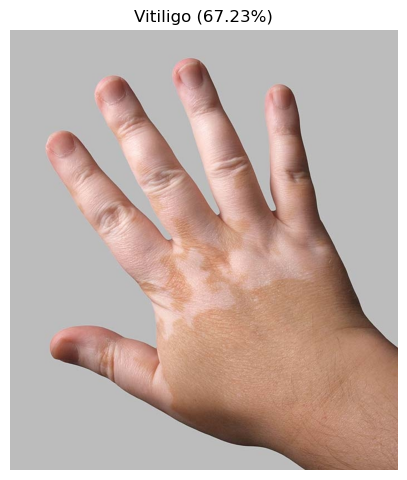

🧬 Detected Disease: Vitiligo
🧪 Disease Percentage: 67.23 %

💊 Recommended Treatment:
• Topical Corticosteroids
• Phototherapy


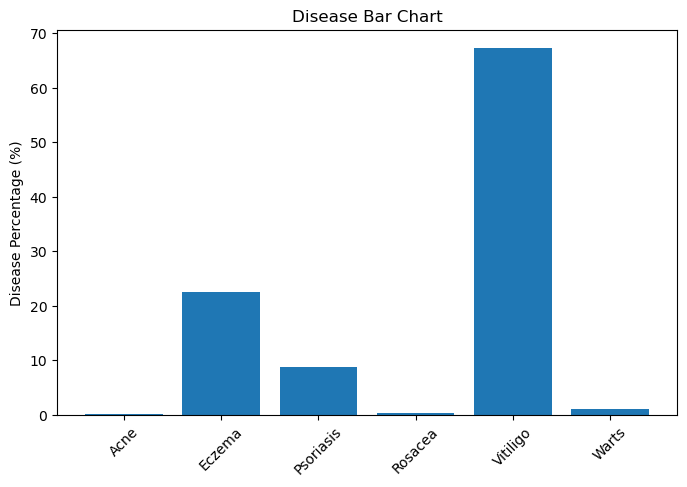

In [37]:
IMG_PATH = r"C:\Users\user\Downloads\diseases\Vitiligo\1.jpg"
IMG_SIZE = 224

# Read image
img = cv2.imread(IMG_PATH)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Preprocess
img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
img_array = img_resized / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
pred = model.predict(img_array)[0]

# Disease percentage
disease_percentages = pred * 100
predicted_index = np.argmax(pred)
predicted_class = class_names[predicted_index]
predicted_percent = disease_percentages[predicted_index]

# ================= IMAGE OUTPUT =================
plt.figure(figsize=(5,6))
plt.imshow(img_rgb)
plt.axis("off")
plt.title(f"{predicted_class} ({predicted_percent:.2f}%)")
plt.show()

# ================= TEXT OUTPUT =================
print("🧬 Detected Disease:", predicted_class)
print(f"🧪 Disease Percentage: {predicted_percent:.2f} %")

print("\n💊 Recommended Treatment:")
for c in recommendations.get(predicted_class, ["Consult Dermatologist"]):
    print("•", c)


# ================= BAR CHART =================
plt.figure(figsize=(8,5))
plt.bar(class_names, disease_percentages)
plt.xticks(rotation=45)
plt.ylabel("Disease Percentage (%)")
plt.title("Disease Bar Chart")
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step


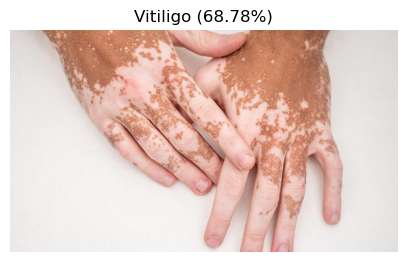

🧬 Detected Disease: Vitiligo
🧪 Disease Percentage: 68.78 %

💊 Recommended Treatment:
• Topical Corticosteroids
• Phototherapy


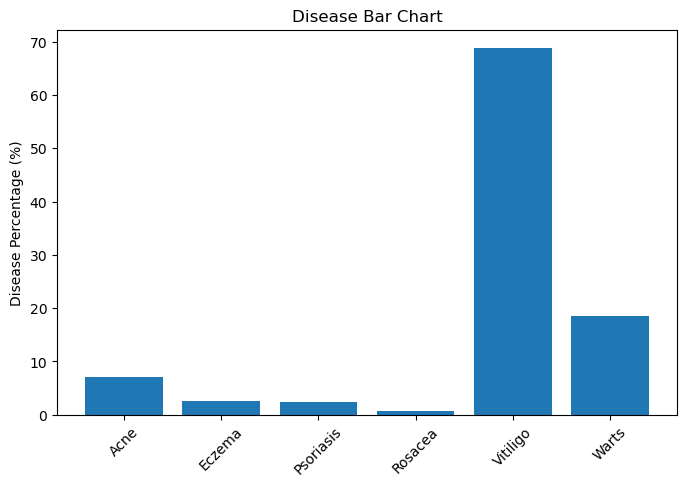

In [38]:
IMG_PATH = r"C:\Users\user\Downloads\diseases\Vitiligo\2.jpg"
IMG_SIZE = 224

# Read image
img = cv2.imread(IMG_PATH)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Preprocess
img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
img_array = img_resized / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
pred = model.predict(img_array)[0]

# Disease percentage
disease_percentages = pred * 100
predicted_index = np.argmax(pred)
predicted_class = class_names[predicted_index]
predicted_percent = disease_percentages[predicted_index]

# ================= IMAGE OUTPUT =================
plt.figure(figsize=(5,6))
plt.imshow(img_rgb)
plt.axis("off")
plt.title(f"{predicted_class} ({predicted_percent:.2f}%)")
plt.show()

# ================= TEXT OUTPUT =================
print("🧬 Detected Disease:", predicted_class)
print(f"🧪 Disease Percentage: {predicted_percent:.2f} %")

print("\n💊 Recommended Treatment:")
for c in recommendations.get(predicted_class, ["Consult Dermatologist"]):
    print("•", c)


# ================= BAR CHART =================
plt.figure(figsize=(8,5))
plt.bar(class_names, disease_percentages)
plt.xticks(rotation=45)
plt.ylabel("Disease Percentage (%)")
plt.title("Disease Bar Chart")
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step


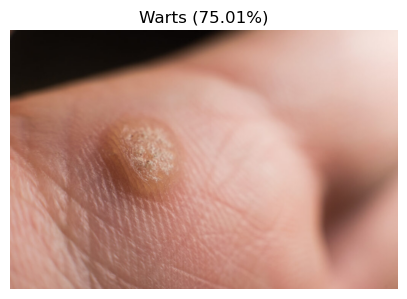

🧬 Detected Disease: Warts
🧪 Disease Percentage: 75.01 %

💊 Recommended Treatment:
• Salicylic Acid
• Cryotherapy


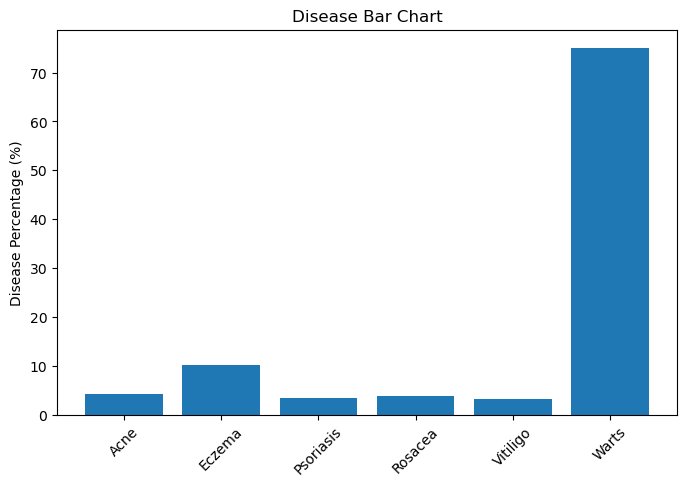

In [39]:
IMG_PATH = r"C:\Users\user\Downloads\diseases\Warts\2.jpeg"
IMG_SIZE = 224

# Read image
img = cv2.imread(IMG_PATH)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Preprocess
img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
img_array = img_resized / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
pred = model.predict(img_array)[0]

# Disease percentage
disease_percentages = pred * 100
predicted_index = np.argmax(pred)
predicted_class = class_names[predicted_index]
predicted_percent = disease_percentages[predicted_index]

# ================= IMAGE OUTPUT =================
plt.figure(figsize=(5,6))
plt.imshow(img_rgb)
plt.axis("off")
plt.title(f"{predicted_class} ({predicted_percent:.2f}%)")
plt.show()

# ================= TEXT OUTPUT =================
print("🧬 Detected Disease:", predicted_class)
print(f"🧪 Disease Percentage: {predicted_percent:.2f} %")

print("\n💊 Recommended Treatment:")
for c in recommendations.get(predicted_class, ["Consult Dermatologist"]):
    print("•", c)


# ================= BAR CHART =================
plt.figure(figsize=(8,5))
plt.bar(class_names, disease_percentages)
plt.xticks(rotation=45)
plt.ylabel("Disease Percentage (%)")
plt.title("Disease Bar Chart")
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step


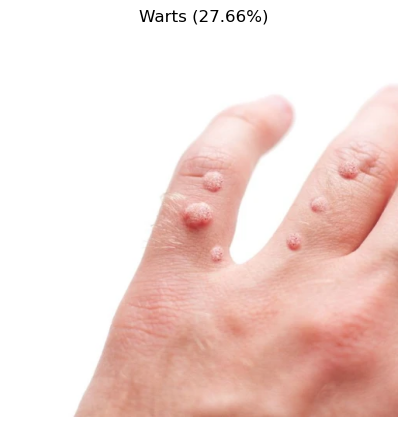

🧬 Detected Disease: Warts
🧪 Disease Percentage: 27.66 %

💊 Recommended Treatment:
• Salicylic Acid
• Cryotherapy


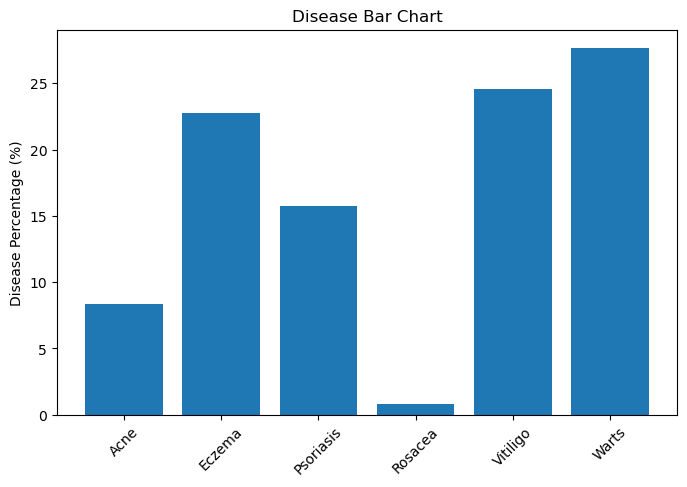

In [41]:
IMG_PATH = r"C:\Users\user\Downloads\diseases\Warts\4.webp"
IMG_SIZE = 224

# Read image
img = cv2.imread(IMG_PATH)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Preprocess
img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
img_array = img_resized / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
pred = model.predict(img_array)[0]

# Disease percentage
disease_percentages = pred * 100
predicted_index = np.argmax(pred)
predicted_class = class_names[predicted_index]
predicted_percent = disease_percentages[predicted_index]

# ================= IMAGE OUTPUT =================
plt.figure(figsize=(5,6))
plt.imshow(img_rgb)
plt.axis("off")
plt.title(f"{predicted_class} ({predicted_percent:.2f}%)")
plt.show()

# ================= TEXT OUTPUT =================
print("🧬 Detected Disease:", predicted_class)
print(f"🧪 Disease Percentage: {predicted_percent:.2f} %")

print("\n💊 Recommended Treatment:")
for c in recommendations.get(predicted_class, ["Consult Dermatologist"]):
    print("•", c)


# ================= BAR CHART =================
plt.figure(figsize=(8,5))
plt.bar(class_names, disease_percentages)
plt.xticks(rotation=45)
plt.ylabel("Disease Percentage (%)")
plt.title("Disease Bar Chart")
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step


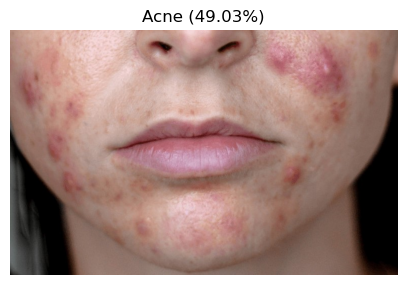

🧬 Detected Disease: Acne
🧪 Disease Percentage: 49.03 %

💊 Recommended Treatment:
• Benzoyl Peroxide
• Salicylic Acid


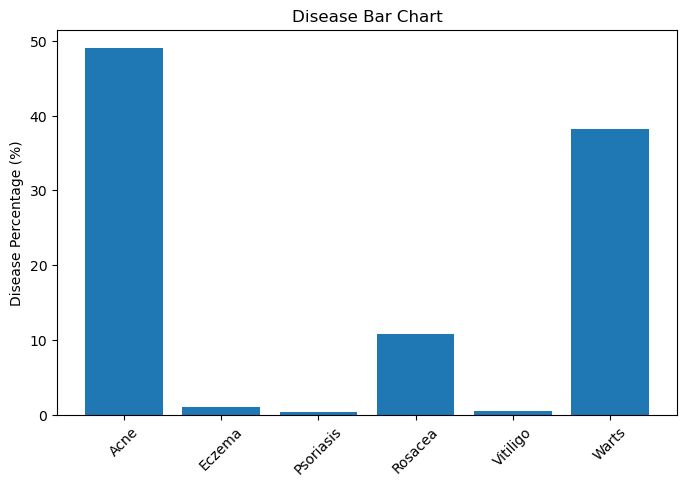

In [44]:
IMG_PATH = r"C:\Users\user\Downloads\diseases\Acne\3.jpg"
IMG_SIZE = 224

# Read image
img = cv2.imread(IMG_PATH)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Preprocess
img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
img_array = img_resized / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
pred = model.predict(img_array)[0]

# Disease percentage
disease_percentages = pred * 100
predicted_index = np.argmax(pred)
predicted_class = class_names[predicted_index]
predicted_percent = disease_percentages[predicted_index]

# ================= IMAGE OUTPUT =================
plt.figure(figsize=(5,6))
plt.imshow(img_rgb)
plt.axis("off")
plt.title(f"{predicted_class} ({predicted_percent:.2f}%)")
plt.show()

# ================= TEXT OUTPUT =================
print("🧬 Detected Disease:", predicted_class)
print(f"🧪 Disease Percentage: {predicted_percent:.2f} %")

print("\n💊 Recommended Treatment:")
for c in recommendations.get(predicted_class, ["Consult Dermatologist"]):
    print("•", c)


# ================= BAR CHART =================
plt.figure(figsize=(8,5))
plt.bar(class_names, disease_percentages)
plt.xticks(rotation=45)
plt.ylabel("Disease Percentage (%)")
plt.title("Disease Bar Chart")
plt.show()
